# Transition Matrix vs Monte Carlo Methods for Heterogeneous-Agent Models

By William Du (wdu9@jhu.edu), with subsequent revisions by Chris Carroll (ccarroll@llorracc.org)

Heterogeneous-agent models require computing the distribution of agents
across individual states (wealth, income, etc.) and tracking how that
distribution evolves over time.  Two broad approaches exist:

- **Monte Carlo (MC) simulation** tracks a finite panel of agents who each
  draw idiosyncratic shocks.  Aggregates are sample means.  The method is
  unbiased but noisy: sampling error scales as $1/\sqrt{N}$.
- **Transition matrix (TM) methods** discretise the state space onto a grid
  and represent the law of motion as a Markov transition matrix.  The
  distribution is propagated forward by matrix–vector multiplication, giving
  deterministic (noise-free) aggregates at the cost of discretisation error.

This notebook compares the two approaches in a standard incomplete-markets
consumption–savings model
([Bewley, 1986](https://doi.org/10.1016/0022-0531(86)90034-3);
[Aiyagari, 1994](https://doi.org/10.2307/2118417)),
implemented in HARK's `NewKeynesianConsumerType`.  The notebook proceeds in
three parts:

1. **Steady state:** Solve the infinite-horizon problem, compute the ergodic
   distribution by both MC and TM, and compare accuracy and precision.
2. **Harmenberg neutral measure:** Show how the reweighting trick of
   [Harmenberg (2021)](https://doi.org/10.1016/j.jedc.2021.104185) collapses
   the 2D $(m, p)$ grid to a 1D $m$ grid, dramatically improving TM
   efficiency.
3. **Perfect-foresight transition path:** Compute the economy's nonlinear
   response to an anticipated interest-rate deviation — the building block
   for sequence-space Jacobians
   ([Auclert, Bardóczy, Rognlie, and Straub, 2021](https://doi.org/10.3982/ECTA17434))
   — and compare TM and MC performance.

The three key HARK **legacy** methods used throughout are:

- `define_distribution_grid()` — constructs the discretised state-space grid
- `calc_transition_matrix()` — builds the Markov transition matrix from
  the solved policy functions
- `calc_ergodic_dist()` — finds the stationary distribution (left
  eigenvector associated with eigenvalue 1)

Throughout each section, companion cells marked **"New API"** demonstrate
the equivalent workflow using HARK's new general-purpose `AgentSimulator`
(accessed via `initialize_sym()` / `_simulator`), which replaces the above
methods with a model-file-driven approach.  See the
[Appendix](#Appendix:-Legacy-to-New-API-Migration-Guide) for a full mapping
table.

## Set up Computational Environment

In [1]:
import gc
import time
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse as sp

from HARK.ConsumptionSaving.ConsNewKeynesianModel import (
    NewKeynesianConsumerType,
    init_newkeynesian,
)
from HARK.distributions import Lognormal as LognormalDist
from HARK.utilities import jump_to_grid_2D

COLOR_MC = "tab:blue"
COLOR_TM = "tab:orange"
COLOR_HARM = "tab:green"

plt.rcParams.update(
    {
        "figure.figsize": (14, 6),
        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "legend.fontsize": 13,
        "lines.linewidth": 2.5,
    }
)

BURNIN = 500
N_MC_BINS = 200
N_P_DISC = 50
MAX_P_FAC = 10.0

timings = {}


def correct_newborn_dist(agent, param_dict, n_p_disc=N_P_DISC):
    """Patch the TM newborn distribution to match MC's lognormal pLvl init.

    HARK hardcodes newborns at pLvl=1.0.  This subtracts the default
    newborn column and adds a lognormal-distributed replacement so that
    TM and MC solve the same economic model.
    """
    p_init = LognormalDist(
        mu=param_dict["pLogInitMean"], sigma=param_dict["pLogInitStd"]
    )
    p_init_d = p_init.discretize(n_p_disc)
    p_vals_init = p_init_d.atoms.flatten()
    p_prbs_init = p_init_d.pmv.flatten()

    shk_prbs = agent.IncShkDstn[0].pmv
    old_NBD = jump_to_grid_2D(
        np.ones_like(shk_prbs),
        np.ones_like(shk_prbs),
        shk_prbs,
        agent.dist_mGrid,
        agent.dist_pGrid,
    )
    new_NBD = jump_to_grid_2D(
        np.ones(n_p_disc),
        p_vals_init,
        p_prbs_init,
        agent.dist_mGrid,
        agent.dist_pGrid,
    )
    live_prob = agent.LivPrb[0]
    correction = (1.0 - live_prob) * (new_NBD - old_NBD)
    agent.tran_matrix += correction[:, np.newaxis]


def create_finite_horizon_agent(
    ss_agent, param_dict, T_cycle, shock_t, dx, orig_IncShkDstn
):
    """Create a finite-horizon agent for perfect-foresight transition paths.

    Returns a solved agent with time-varying Rfree that includes a one-period
    interest-rate deviation of size dx at period shock_t.
    """
    params = deepcopy(param_dict)
    params["T_cycle"] = T_cycle
    params["LivPrb"] = T_cycle * [ss_agent.LivPrb[0]]
    params["PermGroFac"] = T_cycle * [1.0]
    params["PermShkStd"] = T_cycle * [ss_agent.PermShkStd[0]]
    params["TranShkStd"] = T_cycle * [ss_agent.TranShkStd[0]]
    params["tax_rate"] = T_cycle * [ss_agent.tax_rate[0]]
    params["labor"] = T_cycle * [ss_agent.labor[0]]
    params["wage"] = T_cycle * [ss_agent.wage[0]]
    params["Rfree"] = T_cycle * [ss_agent.Rfree]
    params["DiscFac"] = T_cycle * [ss_agent.DiscFac]

    agent = NewKeynesianConsumerType(**params)
    agent.cycles = 1

    agent.del_from_time_inv("Rfree")
    agent.add_to_time_vary("Rfree")
    agent.del_from_time_inv("DiscFac")
    agent.add_to_time_vary("DiscFac")

    # Use the ORIGINAL income distribution — not the neutral-measure version
    agent.IncShkDstn = T_cycle * [orig_IncShkDstn]
    # Set the FULL terminal solution (not just cFunc_terminal_, which the
    # solver ignores — it reads solution_terminal instead)
    agent.solution_terminal = deepcopy(ss_agent.solution[0])

    R = ss_agent.Rfree[0]
    agent.Rfree = shock_t * [R] + [R + dx] + (T_cycle - shock_t - 1) * [R]

    return agent


def jump_to_grid_fast(m_vals, probs, dist_mGrid):
    """Distribute probability mass onto a grid, preserving means.

    Like HARK's jump_to_grid_1D but with a simpler interface.  Each value
    in m_vals has its probability split between the two nearest grid points
    using linear interpolation weights.
    """
    probGrid = np.zeros(len(dist_mGrid))
    mIndex = np.digitize(m_vals, dist_mGrid) - 1
    mIndex[m_vals <= dist_mGrid[0]] = -1
    mIndex[m_vals >= dist_mGrid[-1]] = len(dist_mGrid) - 1

    for i in range(len(m_vals)):
        if mIndex[i] == -1:
            mlowerIndex = 0
            mupperIndex = 0
            mlowerWeight = 1.0
            mupperWeight = 0.0
        elif mIndex[i] == len(dist_mGrid) - 1:
            mlowerIndex = -1
            mupperIndex = -1
            mlowerWeight = 1.0
            mupperWeight = 0.0
        else:
            mlowerIndex = mIndex[i]
            mupperIndex = mIndex[i] + 1
            mlowerWeight = (dist_mGrid[mupperIndex] - m_vals[i]) / (
                dist_mGrid[mupperIndex] - dist_mGrid[mlowerIndex]
            )
            mupperWeight = 1.0 - mlowerWeight

        probGrid[mlowerIndex] += probs[i] * mlowerWeight
        probGrid[mupperIndex] += probs[i] * mupperWeight

    return probGrid.flatten()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Calibration

We use the quarterly infinite-horizon calibration from
[Carroll, Slacalek, Tokuoka, and White (2017)](https://doi.org/10.3982/QE694) ("cstwMPC"), which targets the U.S. wealth
distribution and aggregate capital-output ratio.

The cstwMPC paper estimates a *distribution* of discount factors
$\beta \sim U(\bar\beta - \nabla, \bar\beta + \nabla)$ across agent types
(the "$\beta$-Dist" model) to jointly match the aggregate $K/Y$ ratio and the
Lorenz curve of the wealth distribution.  Because this notebook uses a single
agent type, we adopt the "$\beta$-Point" estimate: a single homogeneous
$\beta = 0.9867$ chosen to match $K/Y$.  (The $\beta$-Point model matches
aggregate wealth but produces a more compressed wealth distribution than the
$\beta$-Dist specification.)

| Symbol | Parameter | Value | Source / Rationale |
|--------|-----------|-------|--------------------|
| $\rho$ | CRRA | 1.01 | Near-log utility (1.01 for numerical stability) |
| $R$ | Gross interest factor | $1.01 / D \approx 1.016$ | Mortality-adjusted quarterly rate (1.01 gross / survival prob) |
| $\beta$ | Discount factor | 0.9867 | $\beta$-Point estimate from cstwMPC |
| $D$ | Survival probability | $1 - 1/160 = 0.99375$ | Blanchard–Yaari, 40-year expected life |
| $\Gamma$ | Permanent income growth | 1.00 | Normalised (infinite horizon) |
| $\sigma_\psi$ | Permanent shock std | $(0.01 \times 4/11)^{1/2} \approx 0.060$ | Sabelhaus & Song (2010) estimates, converted to quarterly |
| $\sigma_\theta$ | Transitory shock std | $(0.01 \times 4)^{1/2} = 0.200$ | Sabelhaus & Song (2010) estimates, converted to quarterly |
| $\wp$ | Unemployment probability | 0.07 | Quarterly job-separation rate |
| $\mu$ | Unemployment benefit | 0.15 | 15 % of permanent income |

The income process discretisation uses 7 points for each shock (permanent and
transitory), giving a $7 \times 7 = 49$-point joint distribution per period
plus the unemployment state.

The replication code for the cstwMPC paper is in the
[DistributionOfWealthMPC](https://github.com/econ-ark/DistributionOfWealthMPC)
repository; the authoritative parameter values are in
[`code/calibration.py`](https://github.com/econ-ark/DistributionOfWealthMPC/blob/master/code/calibration.py).

In [2]:
# Start from HARK's NewKeynesian defaults (infinite horizon, cycles=0)
# and override with cstwMPC quarterly calibration (Carroll et al. 2017).
LivPrb_quarterly = 1.0 - 1.0 / 160.0  # Blanchard–Yaari, ≈ 40-year expected life

Dict = {
    **init_newkeynesian,
    # --- Preferences (cstwMPC β-Point) ---
    "CRRA": 1.01,  # near-log utility
    "Rfree": [1.01 / LivPrb_quarterly],  # mortality-adjusted quarterly rate
    "DiscFac": 0.9867,  # β-Point estimate
    "LivPrb": [LivPrb_quarterly],
    # --- Income process (Sabelhaus & Song 2010, via cstwMPC) ---
    "PermShkStd": [(0.01 * 4 / 11) ** 0.5],  # ≈ 0.0603
    "TranShkStd": [(0.01 * 4) ** 0.5],  # = 0.2
    "UnempPrb": 0.07,
    "IncUnemp": 0.15,
    "UnempPrbRet": 0.0005,
    # --- Simulation ---
    "AgentCount": 200000,
    "T_sim": 2000,
    "pLogInitStd": 0.4,  # initial pLvl dispersion (cstwMPC life-cycle, SCF young households)
    "pLogInitMean": -0.5 * 0.4**2,  # Jensen correction so E[pLvl] = 1.0
    "pLvlInitCount": 25,  # discretization of newborn pLvl (default 15 is adequate but 25 is smoother)
    "kLogInitMean": np.log(0.000001),  # newborns start with ~zero assets
    "kLogInitStd": 0.0,
    # --- Solution grid (EGM) ---
    "aXtraMin": 0.0001,
    "aXtraMax": 150,
    "aXtraCount": 130,
    "aXtraNestFac": 2,  # double-exponential, matching TM grid (mFac)
    # --- Transition matrix grid ---
    # mMax=150, matching the SSJ one-asset HANK example (Auclert et al. 2021,
    # https://github.com/shade-econ/sequence-jacobian/blob/master/notebooks/hank.ipynb).
    "mMin": 1e-4,
    "mMax": 150,
    "mCount": 100,
    "mFac": 2,  # timestonest=2 → double-exponential grid, matching SSJ asset_grid
}

## Solve the Infinite-Horizon Problem

We create a `NewKeynesianConsumerType` with the calibration above and solve
for the consumption function $c(m)$ by iterating the Bellman equation to
convergence.  The resulting policy function is the foundation for everything
that follows: the transition matrices are constructed from it, and it serves
as the terminal condition for the finite-horizon backward induction used to
compute transition paths.

The agent's one-period problem is

$$
v(m) = \max_{c} \; u(c) + \beta \, \wp \, \mathbb{E}\!\left[ \Gamma \psi \right]^{1-\rho} \, \mathbb{E}\!\left[ v\!\left(\frac{R \, a + \Gamma \psi \xi}{\Gamma \psi}\right) \right]
$$

where $m$ is market resources (cash-on-hand) normalized by permanent income,
$c$ is consumption, $a = m - c$ is end-of-period assets, $u(c) = c^{1-\rho}/(1-\rho)$
is CRRA utility, $\beta$ is the discount factor, $\wp$ is the survival
probability (`LivPrb`), $R$ is the gross interest rate, $\Gamma$ is the
permanent income growth factor, and $\psi$, $\xi$ are the permanent and
transitory income shocks drawn from the distributions specified in the
calibration.  HARK solves this problem using the endogenous grid method (EGM)
of [Carroll (2006)](https://doi.org/10.1016/j.econlet.2005.09.013).

**Note on the class name.** Despite the name, `NewKeynesianConsumerType` is
used here solely because it provides HARK's transition-matrix infrastructure
(`define_distribution_grid`, `calc_transition_matrix`, `calc_ergodic_dist`).
The model solved in this notebook is a standard incomplete-markets
consumption–savings problem with no New Keynesian features (no price
rigidities, no Phillips curve, no monetary policy rule).

In [3]:
example1 = NewKeynesianConsumerType(**Dict)
example1.solve()

## Part 1: Steady-State Comparison — Transition Matrix vs Monte Carlo

Before computing transition dynamics, we need to verify that the two methods
agree on the steady state.  Any discrepancy here signals a problem with the
TM grid (too coarse, too narrow, or poorly placed) that would corrupt all
subsequent dynamic calculations.  We compute the ergodic distribution by
both MC (long simulation with burn-in) and TM (eigenvector of the transition
matrix), then compare aggregate consumption and aggregate assets.

### Method 1: Monte Carlo simulation

We simulate 200,000 agents for 1,100 periods and discard the first 500 as
burn-in.  Each agent independently draws permanent and transitory income
shocks each period and follows the optimal consumption rule $c(m)$.
Post-burn-in sample means of consumption and assets give the MC estimate of
steady-state aggregates.

In [4]:
# Simulate (pLogInitStd=0.4 in Dict gives newborns lognormal pLvl dispersion,
# eliminating the lattice artifact from discrete permanent shocks)
example1.track_vars = ["aLvl"]  # Track level of assets
example1.initialize_sim()
example1.simulate()  # Simulate with Monte Carlo

# Compute Aggregate Consumption and Aggregate Assets
Monte_Carlo_Consumption = np.mean(
    (example1.state_now["mNrm"] - example1.state_now["aNrm"])
    * example1.state_now["pLvl"],
)  # Aggregate Consumption
Monte_Carlo_Assets = np.mean(
    example1.state_now["aNrm"] * example1.state_now["pLvl"],
)  # Aggregate Assets

### Method 2: Transition matrices (without Harmenberg)

The TM approach discretises the joint $(m, p)$ state space onto a 2D grid.
Given the policy function $c(m)$, the end-of-period asset rule
$a(m) = m - c(m)$ maps each grid point to a next-period position; the
income-shock distribution then determines which grid points are reached.
This yields a column-stochastic Markov matrix $\mathbf{T}$ whose
left eigenvector (for eigenvalue 1) is the ergodic distribution.

Without the Harmenberg neutral measure, the grid must cover both the
normalised market resources $m$ and permanent income $p$ dimensions, making
the matrix large and the computation slow.  We demonstrate this first to
motivate the Harmenberg improvement below.

**Grid construction.**  The market-resources grid is built by HARK's
`make_grid_exp_mult` function, which places points on a nonlinearly spaced
grid that concentrates density near the borrowing constraint — where the
consumption function has the most curvature.  With `timestonest=2` (set
via `mFac` in the calibration), the construction applies $\ln(1+x)$ twice
to the grid bounds, creates a uniform grid in the transformed space, then
inverts with $\exp(x)-1$ twice.  The resulting grid is
$a_i = e^{e^{u_i} - 1} - 1$ (a **double-exponential** grid), which is
equivalent to the `asset_grid` function in the
[Auclert, Bardóczy, Rognlie, and Straub (2021)](https://doi.org/10.3982/ECTA17434)
SSJ toolkit
([source](https://github.com/shade-econ/sequence-jacobian/blob/master/src/sequence_jacobian/utilities/discretize.py)).
This grid type puts roughly 30% of its points below $m = 1$, heavily
over-representing the region near the constraint where the policy function
curves most sharply and where most of the ergodic mass resides.  The upper
bound `mMax = 150` matches the SSJ one-asset HANK example
([`hank.ipynb`](https://github.com/shade-econ/sequence-jacobian/blob/master/notebooks/hank.ipynb)).

The number of grid points for $m$ varies in the literature.
[Young (2010)](https://doi.org/10.1016/j.jebo.2009.06.010) uses
150–500 asset grid points for non-stochastic simulation;
[Winberry (2018)](https://doi.org/10.3982/QE740) uses 50–100 per dimension;
and the SSJ toolkit's HANK example uses 500.  We use 100 $m$-points for the
2D (non-Harmenberg) computation below and 1,000 for the 1D Harmenberg
computation, reflecting the much smaller matrix size in the latter case.

In [5]:
t0 = time.time()
# max_p_fac=10 keeps p-grid within ~exp(7.6) ≈ 2000, covering 99.99%+ of mass.
# The default (30) extends p to ~exp(23) ≈ 7.7e9, creating asset-in-levels weights
# up to 7.6e13 that amplify machine-epsilon noise into visible aggregate drift
# when iterating the transition matrix forward.
example1.define_distribution_grid(num_pointsP=110, max_p_fac=MAX_P_FAC)
t1 = time.time()
p_grid_2d = example1.dist_pGrid

example1.calc_transition_matrix()
correct_newborn_dist(example1, Dict)

t2 = time.time()
c_2d = example1.cPol_Grid
asset_2d = example1.aPol_Grid

example1.calc_ergodic_dist()
t3 = time.time()
vecDstn = example1.vec_erg_dstn

n_m_grid = len(example1.dist_mGrid)
n_p_grid = len(p_grid_2d)
n_agents = example1.AgentCount
grid_size = n_m_grid * n_p_grid
print(f"Grid: {n_m_grid} m-points × {n_p_grid} p-points = {grid_size} states")
print(f"  define_distribution_grid : {t1 - t0:6.2f}s")
print(f"  calc_transition_matrix   : {t2 - t1:6.2f}s")
print(f"  calc_ergodic_dist        : {t3 - t2:6.2f}s")
print(f"  Total                    : {t3 - t0:6.2f}s")

Grid: 100 m-points × 221 p-points = 22100 states
  define_distribution_grid :   0.00s
  calc_transition_matrix   :   3.05s
  calc_ergodic_dist        :   9.04s
  Total                    :  12.09s


In [6]:
# Compute Aggregate Consumption and Aggregate Assets (in levels = normalized × pLvl)
gridc = np.outer(c_2d, p_grid_2d)
grida = np.outer(asset_2d, p_grid_2d)

AggC = np.dot(gridc.flatten(), vecDstn)
AggA = np.dot(grida.flatten(), vecDstn)

### Comparing steady-state aggregates

The table below compares aggregate consumption and assets from the two
methods.  The TM values are deterministic (no sampling error), so any
difference from the MC mean reflects discretisation bias in the TM grid.
The MC values fluctuate from run to run; the reported figures are
post-burn-in time-series means.

In [7]:
print("TranMatrix Assets = " + str(AggA))
print("Simulated Assets = " + str(Monte_Carlo_Assets))

print("TranMatrix Consumption = " + str(AggC))
print("Simulated Consumption = " + str(Monte_Carlo_Consumption))

TranMatrix Assets = [3.02317438]
Simulated Assets = 2.99749135938871
TranMatrix Consumption = [1.03017046]
Simulated Consumption = 1.031205994813632


### New API: Transition matrices via `AgentSimulator`

HARK's new simulation system provides a general-purpose `AgentSimulator` class
(in `HARK.simulator`) that can build transition matrices directly from a
model specification file, without relying on hand-coded methods like
`define_distribution_grid()` and `calc_transition_matrix()`.

The workflow is:
1. `agent.initialize_sym()` — parses the YAML model file and creates an
   `AgentSimulator` in `agent._simulator`
2. `agent._simulator.make_transition_matrices(grid_specs)` — builds the
   transition matrix from the solved policy functions
3. `agent._simulator.find_steady_state()` — computes the ergodic distribution
4. `agent._simulator.get_long_run_average(var)` — returns a population average

The `grid_specs` dictionary replaces the old `define_distribution_grid()`
parameters.  Each key names a model variable and maps to a dict with `min`,
`max`, `N`, and optionally `order` (for polynomial spacing).

In [8]:
t0_new = time.time()

# The new simulator only knows variables from the YAML model file.
# Save and restore legacy track_vars around the initialize_sym() call.
_saved_track_vars = example1.track_vars[:]
example1.track_vars = ["cNrm", "aNrm", "mNrm", "pLvl"]
example1.initialize_sym()
example1.track_vars = _saved_track_vars
X = example1._simulator

n_m_2d = len(example1.dist_mGrid)
n_p_2d = len(example1.dist_pGrid)

# Use the legacy double-exponential grids via the "grid" key so the two
# systems share the same state-space discretisation.  The polynomial grids
# produced by make_exponential_grid (order=2-3) lack resolution near the
# borrowing constraint (mNrm ≈ 1), which matters for the density spike.
grid_specs_2d = {
    "kNrm": {"grid": example1.dist_mGrid},
    "pLvlPrev": {"grid": example1.dist_pGrid},
    "mNrm": {"grid": example1.dist_mGrid},
    "cNrm": {"min": 0.0, "max": 5.0, "N": n_m_2d, "order": 3},
    "aNrm": {"grid": example1.dist_mGrid},
}
X.make_transition_matrices(grid_specs_2d)
t1_new = time.time()

X.find_steady_state()
t2_new = time.time()

AggA_new = X.get_long_run_average("aNrm")
AggC_new = X.get_long_run_average("cNrm")

print("=== New AgentSimulator API (2D grid, no Harmenberg) ===")
print(f"  make_transition_matrices : {t1_new - t0_new:6.2f}s")
print(f"  find_steady_state        : {t2_new - t1_new:6.2f}s")
print(f"  Total                    : {t2_new - t0_new:6.2f}s")
print()
print(f"  AgentSimulator Assets = {AggA_new:.6f}")
print(f"  Legacy TM Assets      = {float(np.asarray(AggA).flat[0]):.6f}")
print(f"  AgentSimulator Cons   = {AggC_new:.6f}")
print(f"  Legacy TM Cons        = {float(np.asarray(AggC).flat[0]):.6f}")
print()
print("NOTE: Both systems now share the same double-exponential grids,")
print("so remaining differences reflect the transition-matrix construction")
print("method itself (legacy column-stochastic vs new row-stochastic).")

=== New AgentSimulator API (2D grid, no Harmenberg) ===
  make_transition_matrices :   6.92s
  find_steady_state        :   5.35s
  Total                    :  12.27s

  AgentSimulator Assets = 3.772259
  Legacy TM Assets      = 3.023174
  AgentSimulator Cons   = 1.050668
  Legacy TM Cons        = 1.030170

NOTE: Differences are expected — the two systems use different grid
construction methods (uniform vs exponential spacing).  The 2D case
is particularly sensitive to grid design.  The Harmenberg 1D case
below provides a fairer comparison.


### Simulated path of aggregate assets

The plot below shows the time series of aggregate assets from both methods.
The MC path fluctuates around its mean due to sampling noise; the TM path
is a flat line (the ergodic distribution is a fixed point of $\mathbf{T}$,
so applying the matrix repeatedly leaves it unchanged).  Visual inspection
reveals whether the TM level falls within the MC fluctuation band — a
necessary condition for the TM grid to be adequate.

In [9]:
aLvls = np.array([np.mean(example1.history["aLvl"][i]) for i in range(example1.T_sim)])

aLvls_post_burnin = aLvls[BURNIN:]
MC_mean = np.mean(aLvls_post_burnin)
MC_std = np.std(aLvls_post_burnin, ddof=1)
MC_se = MC_std / np.sqrt(n_agents)
print(
    f"MC aggregate assets: mean = {MC_mean:.6f}, std = {MC_std:.6f}, SE = {MC_se:.6f}"
)

aLvl_tran_mat = []
dstn_fwd = vecDstn
for i in range(example1.T_sim - BURNIN):
    aLvl_tran_mat.append(np.dot(grida.flatten(), dstn_fwd))
    dstn_fwd = np.dot(example1.tran_matrix, dstn_fwd)

MC aggregate assets: mean = 2.989454, std = 0.011324, SE = 0.000025


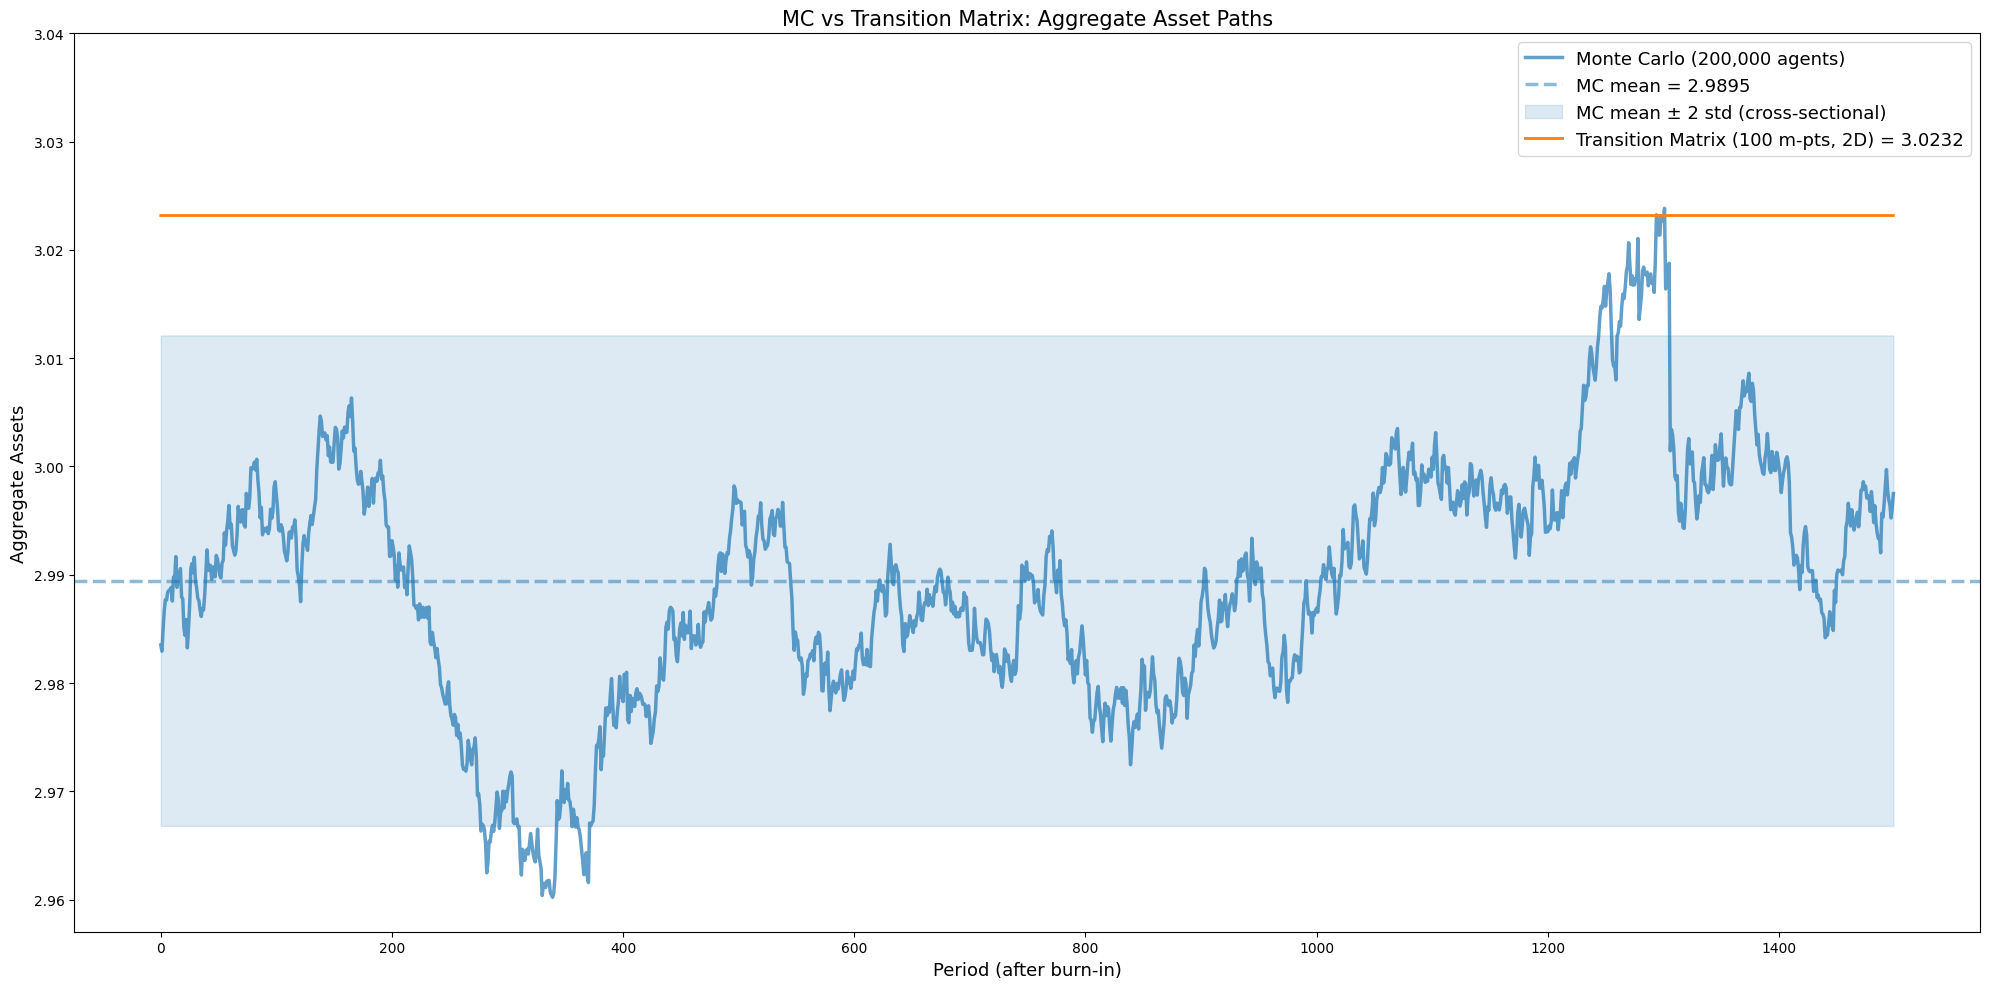

In [10]:
# [mc_vs_tm_asset_paths] Time series of aggregate assets — MC vs TM
plt.figure(figsize=(20, 10))
plt.plot(
    aLvls_post_burnin,
    label=f"Monte Carlo ({n_agents:,} agents)",
    color=COLOR_MC,
    alpha=0.7,
)
plt.axhline(
    MC_mean, color=COLOR_MC, linestyle="--", alpha=0.5, label=f"MC mean = {MC_mean:.4f}"
)
plt.fill_between(
    range(len(aLvls_post_burnin)),
    MC_mean - 2 * MC_std,
    MC_mean + 2 * MC_std,
    alpha=0.15,
    color=COLOR_MC,
    label="MC mean ± 2 std (cross-sectional)",
)
plt.plot(
    aLvl_tran_mat,
    label=f"Transition Matrix ({n_m_grid} m-pts, 2D) = {np.asarray(aLvl_tran_mat[0]).item():.4f}",
    color=COLOR_TM,
    linewidth=2.0,
)
plt.ylabel("Aggregate Assets")
plt.xlabel("Period (after burn-in)")
plt.ylim(top=3.04)
plt.legend()
plt.title("MC vs Transition Matrix: Aggregate Asset Paths")
plt.tight_layout()
plt.show()

### Precision vs Accuracy

The two methods exhibit a **bias–variance tradeoff**:

- **Monte Carlo** is *accurate* (unbiased) but *imprecise*: the aggregate asset path fluctuates because each period draws $N$ independent shocks. The shaded band in the plot above shows the range of typical MC fluctuations (mean ± 2 standard deviations). Increasing $N$ (agent count) shrinks the band proportionally to $1/\sqrt{N}$.

- **Transition matrix** is *precise* (deterministic — a flat horizontal line) but may be *less accurate*: the aggregate level differs from the MC mean because of grid discretization error. With a coarser grid, this bias can be substantial. Increasing the number of grid points reduces the bias.

In statistical terms:

$$\text{MSE} = \text{Bias}^2 + \text{Variance}$$

For MC, $\text{Bias} = 0$ and $\text{Variance} = \sigma^2/N$. For TM, $\text{Variance} = 0$ and $\text{Bias} = O(\Delta g)$, where $\Delta g$ is the grid spacing.

In [11]:
# Quantitative MSE decomposition
# Use the MC time-series mean as a proxy for the true aggregate.
MC_var = np.var(aLvls_post_burnin, ddof=1).item()
TM_bias = np.asarray(aLvl_tran_mat[0]).item() - MC_mean

print("MSE decomposition (aggregate assets):")
print(
    f"  MC  — Bias² = 0 (by construction),  Variance = {MC_var:.2e},  MSE = {MC_var:.2e}"
)
print(
    f"  TM  — Bias² = {TM_bias**2:.2e} (bias = {TM_bias:.6f}),  Variance = 0,  MSE = {TM_bias**2:.2e}"
)
print()
if MC_var < TM_bias**2:
    print(f"  → MC has lower MSE here ({MC_var:.2e} < {TM_bias**2:.2e}).")
    print(
        "    Increasing TM grid points would reduce TM bias (see Harmenberg section below)."
    )
else:
    print(f"  → TM has lower MSE here ({TM_bias**2:.2e} < {MC_var:.2e}).")
    print("    Increasing MC agent count would reduce MC variance.")

MSE decomposition (aggregate assets):
  MC  — Bias² = 0 (by construction),  Variance = 1.28e-04,  MSE = 1.28e-04
  TM  — Bias² = 1.14e-03 (bias = 0.033721),  Variance = 0,  MSE = 1.14e-03

  → MC has lower MSE here (1.28e-04 < 1.14e-03).
    Increasing TM grid points would reduce TM bias (see Harmenberg section below).


### New API: Monte Carlo via `symulate()`

The new simulation system replaces `initialize_sim()` / `simulate()` with
`initialize_sym()` / `symulate()`.  Results are stored in the `hystory`
attribute (note the spelling) rather than `history`.

In [12]:
example1_new = NewKeynesianConsumerType(**Dict)
example1_new.solve()
example1_new.track_vars = ["cNrm", "aNrm", "mNrm", "pLvl"]
example1_new.T_sim = 2000
example1_new.AgentCount = 200000

t0_mc_new = time.time()
example1_new.initialize_sym()
example1_new.symulate()
t1_mc_new = time.time()

aLvls_new = np.array(
    [
        np.mean(example1_new.hystory["aNrm"][i] * example1_new.hystory["pLvl"][i])
        for i in range(example1_new.T_sim)
    ]
)

print("=== New symulate() MC simulation ===")
print(
    f"  Time: {t1_mc_new - t0_mc_new:.2f}s ({example1_new.AgentCount:,} agents, {example1_new.T_sim} periods)"
)
print(f"  Mean assets (post burn-in): {np.mean(aLvls_new[BURNIN:]):.6f}")
print(f"  Legacy MC mean assets:      {Monte_Carlo_Assets:.6f}")

=== New symulate() MC simulation ===
  Time: 62.78s (200,000 agents, 2000 periods)
  Mean assets (post burn-in): 2.983166
  Legacy MC mean assets:      2.997491


## Cross-sectional distributions

The following cells plot the steady-state cross-sectional distributions of
normalised market resources, permanent income, wealth, and liquid assets.
These distributions are a key output of the model and a standard diagnostic
for assessing whether the calibration produces empirically plausible
heterogeneity.

### Distribution of normalised market resources

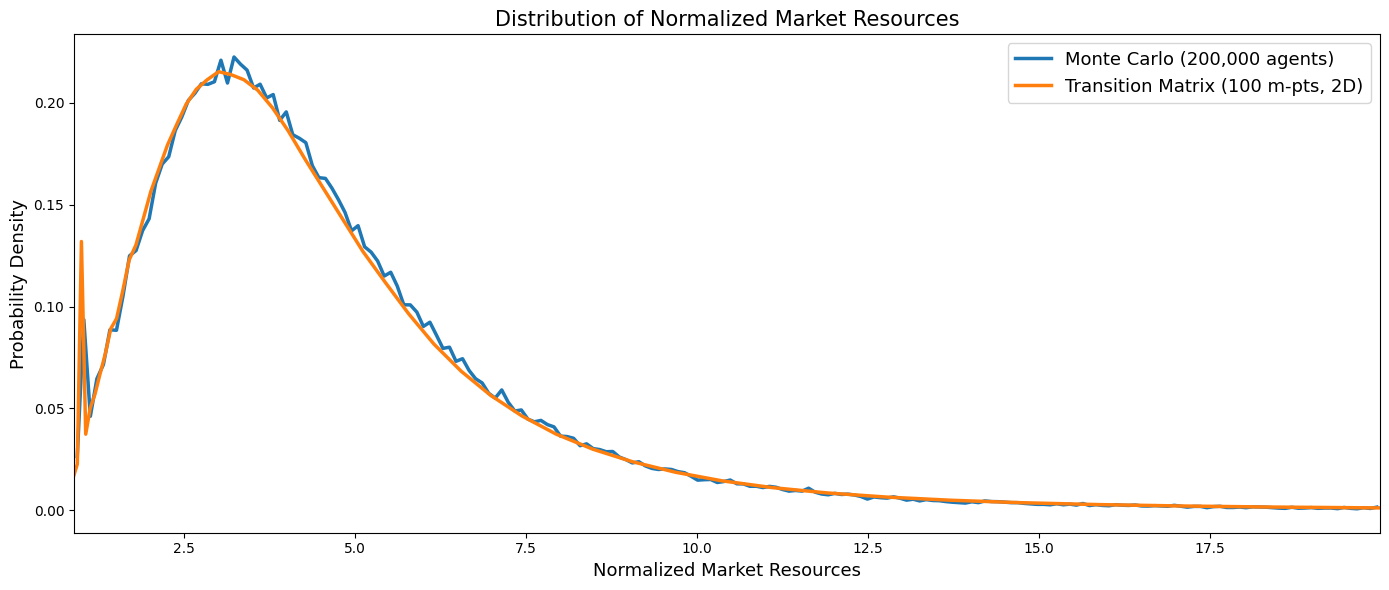

In [13]:
# [dist_normalized_market_resources] Marginal distribution of normalized market resources
mdstn = example1.erg_dstn.sum(axis=1)

m_grid = example1.dist_mGrid
m_mids = 0.5 * (m_grid[:-1] + m_grid[1:])
m_bin_edges = np.concatenate([[m_grid[0]], m_mids, [m_grid[-1]]])
tm_density_m = mdstn / np.diff(m_bin_edges)

mlo = np.percentile(example1.state_now["mNrm"], 0.5)
mhi = np.percentile(example1.state_now["mNrm"], 99.5)
mc_edges = np.linspace(mlo, mhi, N_MC_BINS + 1)
mc_counts, _ = np.histogram(example1.state_now["mNrm"], bins=mc_edges, density=True)
mc_centers = 0.5 * (mc_edges[:-1] + mc_edges[1:])

plt.figure(figsize=(14, 6))
plt.plot(
    mc_centers, mc_counts, label=f"Monte Carlo ({n_agents:,} agents)", color=COLOR_MC
)
plt.plot(
    m_grid,
    tm_density_m,
    label=f"Transition Matrix ({n_m_grid} m-pts, 2D)",
    color=COLOR_TM,
)
plt.ylabel("Probability Density")
plt.xlabel("Normalized Market Resources")
plt.title("Distribution of Normalized Market Resources")
plt.legend()
plt.xlim([mlo, mhi])
plt.tight_layout()
plt.show()

### Distribution of permanent income

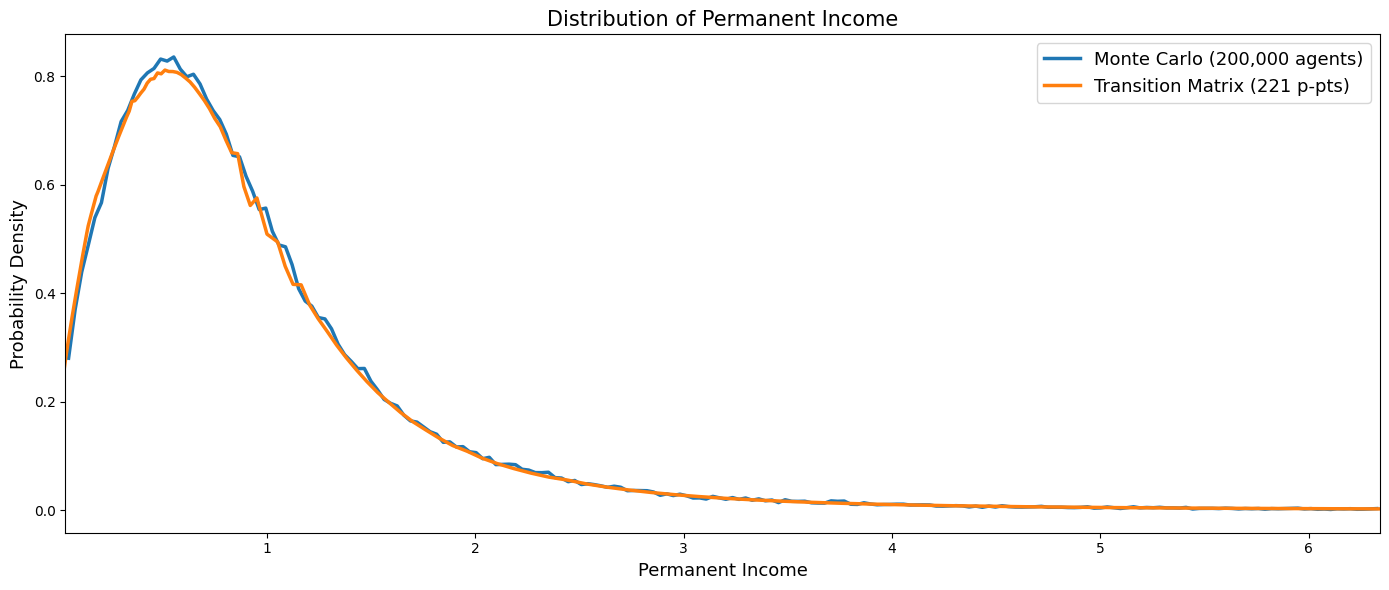

In [14]:
# [dist_permanent_income] Permanent income distribution
pdstn = example1.erg_dstn.sum(axis=0)

p_grid = example1.dist_pGrid
p_mids = 0.5 * (p_grid[:-1] + p_grid[1:])
p_bin_edges = np.concatenate([[p_grid[0]], p_mids, [p_grid[-1]]])
tm_density_p = pdstn / np.diff(p_bin_edges)

plo = np.percentile(example1.state_now["pLvl"], 0.5)
phi = np.percentile(example1.state_now["pLvl"], 99.5)
mc_edges_p = np.linspace(plo, phi, N_MC_BINS + 1)
mc_counts_p, _ = np.histogram(example1.state_now["pLvl"], bins=mc_edges_p, density=True)
mc_centers_p = 0.5 * (mc_edges_p[:-1] + mc_edges_p[1:])

plt.figure(figsize=(14, 6))
plt.plot(
    mc_centers_p,
    mc_counts_p,
    label=f"Monte Carlo ({n_agents:,} agents)",
    color=COLOR_MC,
)
plt.plot(
    p_grid,
    tm_density_p,
    label=f"Transition Matrix ({len(p_grid)} p-pts)",
    color=COLOR_TM,
)
plt.ylabel("Probability Density")
plt.xlabel("Permanent Income")
plt.title("Distribution of Permanent Income")
plt.legend()
plt.xlim([plo, phi])
plt.tight_layout()
plt.show()

### Distribution of wealth

In [15]:
# All possible level values: outer product of normalized grid × permanent income grid
mLvl_vals = np.outer(example1.dist_mGrid, example1.dist_pGrid).ravel()
aLvl_vals = np.outer(example1.aPol_Grid, example1.dist_pGrid).ravel()

In [16]:
# jump_to_grid_fast is defined in the imports/utilities cell above.

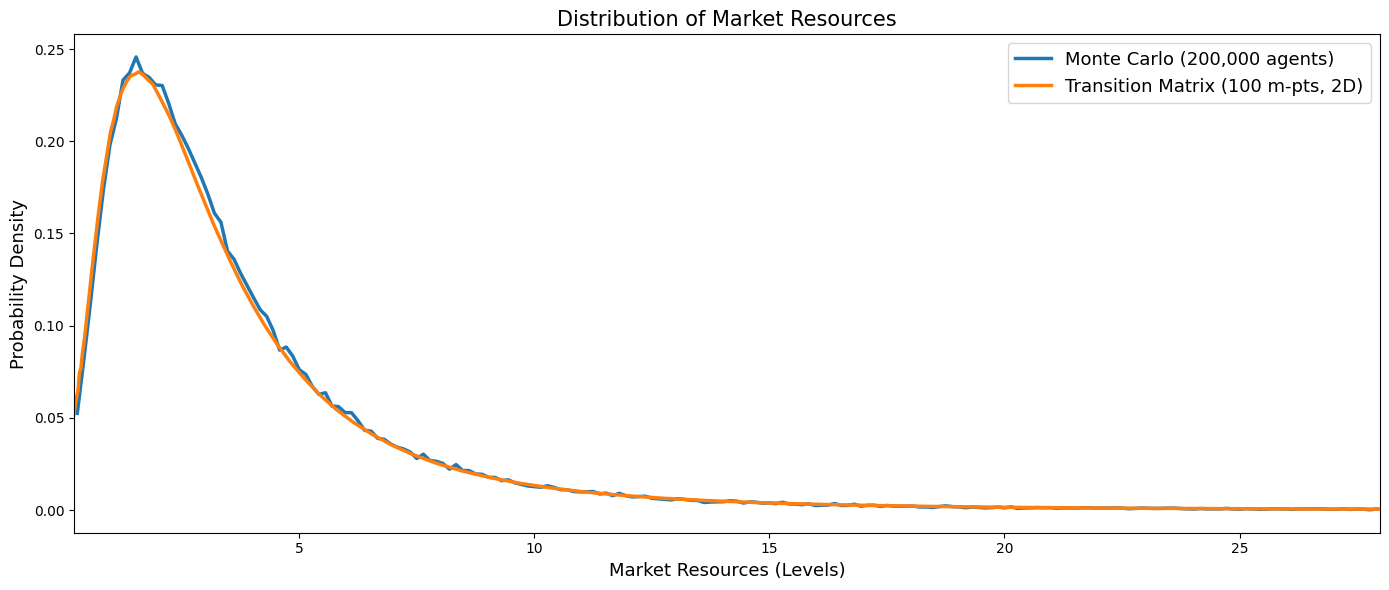

In [17]:
# [dist_market_resources_levels] Market resources in levels
mLvl = example1.state_now["mNrm"] * example1.state_now["pLvl"]
pmf_mLvl = jump_to_grid_fast(mLvl_vals, vecDstn.flatten(), example1.dist_mGrid)

mLvl_grid = example1.dist_mGrid
mLvl_mids = 0.5 * (mLvl_grid[:-1] + mLvl_grid[1:])
mLvl_bin_edges = np.concatenate([[mLvl_grid[0]], mLvl_mids, [mLvl_grid[-1]]])
tm_density_mLvl = pmf_mLvl / np.diff(mLvl_bin_edges)

mLvl_lo = np.percentile(mLvl, 0.5)
mLvl_hi = np.percentile(mLvl, 99.5)
mc_edges_mLvl = np.linspace(mLvl_lo, mLvl_hi, N_MC_BINS + 1)
mc_counts_mLvl, _ = np.histogram(mLvl, bins=mc_edges_mLvl, density=True)
mc_centers_mLvl = 0.5 * (mc_edges_mLvl[:-1] + mc_edges_mLvl[1:])

plt.figure(figsize=(14, 6))
plt.plot(
    mc_centers_mLvl,
    mc_counts_mLvl,
    label=f"Monte Carlo ({n_agents:,} agents)",
    color=COLOR_MC,
)
plt.plot(
    mLvl_grid,
    tm_density_mLvl,
    label=f"Transition Matrix ({n_m_grid} m-pts, 2D)",
    color=COLOR_TM,
)
plt.ylabel("Probability Density")
plt.xlabel("Market Resources (Levels)")
plt.title("Distribution of Market Resources")
plt.legend()
plt.xlim([mLvl_lo, mLvl_hi])
plt.tight_layout()
plt.show()

### Distribution of liquid assets

Fraction at borrowing constraint (a≈0): MC=0.002, TM=0.002


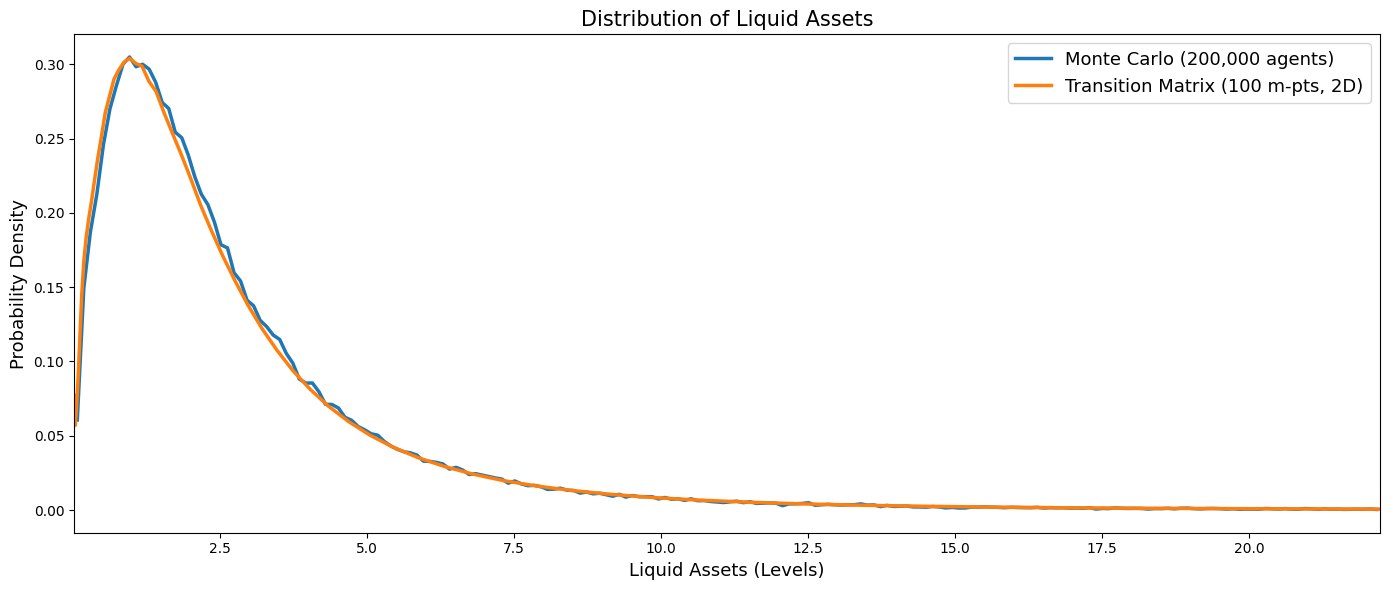

In [18]:
# [dist_liquid_assets] Liquid assets distribution
asset_Lvl = example1.state_now["aLvl"]
pmf_a = jump_to_grid_fast(aLvl_vals, vecDstn.flatten(), example1.aPol_Grid)

# aPol_Grid has repeated zeros at the borrowing constraint; skip them for density
a_start = int(np.searchsorted(example1.aPol_Grid, 1e-8, side="right"))
mc_at_zero = np.mean(asset_Lvl < 1e-8)
tm_at_zero = pmf_a[:a_start].sum()
print(
    f"Fraction at borrowing constraint (a≈0): MC={mc_at_zero:.3f}, TM={tm_at_zero:.3f}"
)

a_grid = example1.aPol_Grid[a_start:]
a_pmf = pmf_a[a_start:]
a_mids = 0.5 * (a_grid[:-1] + a_grid[1:])
a_bin_edges = np.concatenate([[a_grid[0]], a_mids, [a_grid[-1]]])
tm_density_a = a_pmf / np.diff(a_bin_edges)

# MC histogram over the same positive range (excluding mass at zero)
aLvl_lo = max(a_grid[0], 0.0)
aLvl_hi = np.percentile(asset_Lvl, 99.5)
mc_edges_a = np.linspace(aLvl_lo, aLvl_hi, N_MC_BINS + 1)
mc_counts_a, _ = np.histogram(asset_Lvl, bins=mc_edges_a, density=True)
mc_centers_a = 0.5 * (mc_edges_a[:-1] + mc_edges_a[1:])

plt.figure(figsize=(14, 6))
plt.plot(
    mc_centers_a,
    mc_counts_a,
    label=f"Monte Carlo ({n_agents:,} agents)",
    color=COLOR_MC,
)
plt.plot(
    a_grid,
    tm_density_a,
    label=f"Transition Matrix ({n_m_grid} m-pts, 2D)",
    color=COLOR_TM,
)
plt.ylabel("Probability Density")
plt.xlabel("Liquid Assets (Levels)")
plt.title("Distribution of Liquid Assets")
plt.legend()
plt.xlim([aLvl_lo, aLvl_hi])
plt.tight_layout()
plt.show()

### New API: Extracting distributions from `AgentSimulator`

The new API stores the ergodic distribution as a flat vector in
`_simulator.steady_state_dstn`, with state grid points in
`_simulator.state_grids[0]`.  Outcome distributions are obtained via the
projection matrices in `_simulator.outcome_arrays` and corresponding grids
in `_simulator.outcome_grids`.

The cell below extracts the marginal distribution of normalized market
resources from the new API and compares it to the legacy result.

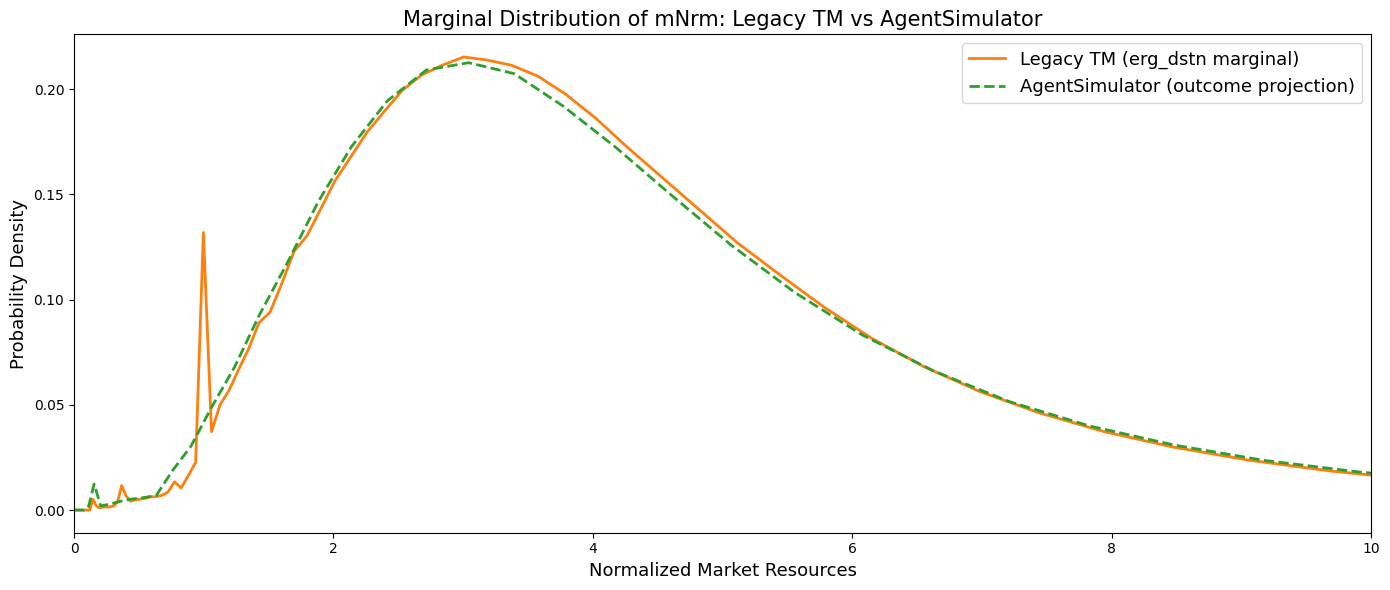

Mean mNrm — Legacy TM: 4.7762, AgentSimulator: 4.8229


In [19]:
# [dist_new_api_market_resources] Distribution of mNrm via AgentSimulator
# The steady-state distribution over the (kNrm, pLvlPrev) arrival state space
# is stored as a flat vector.  To get the marginal over mNrm (an outcome
# variable), multiply the state distribution by the outcome projection matrix.

ss_dstn_2d = X.steady_state_dstn
mNrm_proj = X.outcome_arrays[0]["mNrm"]
mNrm_grid_new = X.outcome_grids[0]["mNrm"]

# Marginal PMF of mNrm from the new API
mNrm_pmf_new = np.dot(ss_dstn_2d, mNrm_proj)

# Convert PMF to density (divide by bin widths) — matching the approach in
# [dist_normalized_market_resources] — so the two grids are visually comparable.
m_mids_new = 0.5 * (mNrm_grid_new[:-1] + mNrm_grid_new[1:])
m_bin_edges_new = np.concatenate([[mNrm_grid_new[0]], m_mids_new, [mNrm_grid_new[-1]]])
new_density = mNrm_pmf_new / np.diff(m_bin_edges_new)

# Legacy marginal — same density conversion as cell [dist_normalized_market_resources]
m_grid_old = example1.dist_mGrid
mdstn_old = example1.erg_dstn.sum(axis=1)
m_mids_old = 0.5 * (m_grid_old[:-1] + m_grid_old[1:])
m_bin_edges_old = np.concatenate([[m_grid_old[0]], m_mids_old, [m_grid_old[-1]]])
old_density = mdstn_old / np.diff(m_bin_edges_old)

plt.figure(figsize=(14, 6))
plt.plot(
    m_grid_old,
    old_density,
    label="Legacy TM (erg_dstn marginal)",
    color=COLOR_TM,
    linewidth=2,
)
plt.plot(
    mNrm_grid_new,
    new_density,
    "--",
    label="AgentSimulator (outcome projection)",
    color="tab:green",
    linewidth=2,
)
plt.ylabel("Probability Density")
plt.xlabel("Normalized Market Resources")
plt.title("Marginal Distribution of mNrm: Legacy TM vs AgentSimulator")
plt.legend()
plt.xlim([0, 10])
plt.tight_layout()
plt.show()

# Quantitative comparison
mean_m_old = np.dot(mdstn_old, m_grid_old)
mean_m_new = np.dot(mNrm_pmf_new, mNrm_grid_new)
print(f"Mean mNrm — Legacy TM: {mean_m_old:.4f}, AgentSimulator: {mean_m_new:.4f}")

## Perfect-Foresight Transition Path for an Anticipated Interest Rate Deviation

This section computes the **perfect-foresight transition path** of aggregate
consumption and aggregate assets in response to an anticipated, temporary
deviation in the real interest rate.

### The experiment

The economy begins in the ergodic steady state computed above. At $t = 0$,
agents learn that the real interest rate will deviate from its steady-state
value by $\Delta r$ in a single period, $t = t^*$, and will return to
its steady-state value in all other periods.  (The code below sets
$\Delta r = -0.01$ and $t^* = 100$ within a $T = 200$ period horizon.)
Because the finite-horizon problem is solved by backward induction over the
full $T$-period horizon, agents' consumption and savings policies at every
date $t = 0, \ldots, T-1$ reflect full knowledge of the anticipated rate
deviation. In particular, policies in the "anticipation window"
$t = 0, \ldots, t^* - 1$ already differ from steady-state policies, so
aggregate quantities begin to move before the rate deviation actually occurs
at $t^*$.

### Relation to the sequence-space Jacobian literature

In the sequence-space Jacobian (SSJ) framework of
[Auclert, Bardóczy, Rognlie, and Straub (2021)](https://doi.org/10.3982/ECTA17434),
general equilibrium impulse responses are computed from Jacobian matrices
whose columns represent the economy's response to single-period perturbations
at each date $s$. Column $s$ of the Jacobian $\mathbf{J}_{C,r}$ gives the
linearized response of the aggregate consumption sequence $\{C_t\}$ to a unit
perturbation in the interest rate at date $s$. The authors describe column $s$
as the effect of *"the 'news' at date 0 that [the variable] will [change] at
time $s$"* (Section 2.2). The present exercise is the nonlinear analogue:
rather than computing a linearized Jacobian column, we solve the full
finite-horizon consumption–savings problem and propagate the distribution
forward to obtain the nonlinear transition path.

The computational method follows the perfect-foresight transition approach
described in [McKay (2023), "Perfect-Foresight Transitions"](https://alisdairmckay.com/Notes/HetAgentsV2/MIT):

1. **Backward induction.** Solve the household's problem backward from
   period $T-1$ to period $0$, using the steady-state value function as the
   terminal condition. Each period's policy function reflects that period's
   interest rate (including the deviation at $t^*$).
2. **Forward propagation.** Starting from the ergodic steady-state
   distribution, propagate the distribution forward using the
   period-specific transition matrices (or, for the Monte Carlo comparison,
   simulate a panel of agents).
3. **Aggregation.** At each date, compute aggregate consumption and assets
   by integrating the policy function against the current distribution.

The transition-matrix method computes steps 2–3 deterministically using
the [Harmenberg (2021)](https://doi.org/10.1016/j.jedc.2021.104185) neutral
measure, which collapses the two-dimensional $(m, p)$ grid to a
one-dimensional $m$ grid. The Monte Carlo method performs the same steps
stochastically by simulating a panel of agents, initialized from the
transition-matrix ergodic distribution via inverse-CDF sampling so that both
methods start from the identical steady state.

**Note on terminology.** This experiment is sometimes loosely called an "MIT
shock," but that term properly refers to an *unanticipated* aggregate
disturbance — a zero-probability event that surprises agents at the moment it
occurs
([Boppart, Krusell, and Mitman, 2018](https://doi.org/10.1016/j.jedc.2017.12.003)).
Here the rate deviation is fully anticipated from $t = 0$, so we use the more
precise term **anticipated deviation** and refer to the resulting dynamics as
a **perfect-foresight transition path** rather than an impulse response
function.


### Compute steady-state distribution (without Harmenberg)

Before introducing the Harmenberg trick, we compute the ergodic distribution
on the full 2D $(m, p)$ grid.  This serves as a baseline: the transition
matrix is large (grid points in $m$ × grid points in $p$) and the computation
is slow, but the result is exact up to discretisation error.

We create a fresh agent `ss` from the same `Dict` rather than reusing
`example1`, because the distribution-grid and transition-matrix methods
(`define_distribution_grid`, `calc_transition_matrix`, etc.) mutate the
agent's internal state.  Keeping a clean `ss` instance ensures that the
Harmenberg setup in Part 2 starts from a pristine state.

In [20]:
ss = NewKeynesianConsumerType(**Dict)
ss.cycles = 0
ss.solve()

## Part 2: The Harmenberg Neutral Measure

In models with permanent income shocks, the cross-sectional distribution of
$p$ spreads out over time, requiring an ever-wider $p$-grid.
[Harmenberg (2021)](https://doi.org/10.1016/j.jedc.2021.104185) shows that
by reweighting the permanent shock probabilities — replacing the physical
measure with a "neutral measure" under which the permanent income distribution
is stationary — one can track aggregates using only the *normalised* market
resources $m = M/p$, collapsing the 2D grid to 1D.

The cost is that the resulting distribution no longer represents the
cross-sectional distribution of levels (wealth in dollars), but aggregate
consumption and assets — which are the objects needed for transition paths
and Jacobians — are computed exactly.  This makes TM methods with Harmenberg
both faster and more accurate than naive 2D TM or MC simulation for the
quantities that matter in general-equilibrium applications.

See also: [Harmenberg aggregation on Econ-ARK](https://econ-ark.org/materials/harmenberg-aggregation?launch).



In [21]:
# Save the ORIGINAL income distribution BEFORE switching to neutral measure.
# The neutral measure reweights shock probabilities for efficient TM tracking,
# but the agent's optimization problem must use the true distribution.
orig_IncShkDstn = deepcopy(ss.IncShkDstn[0])

# Switch to Harmenberg neutral measure BEFORE defining the grid.
# This collapses the 2D (m, p) grid to 1D (m only), making the transition
# matrix vastly smaller and the computation practical at high resolution.
# NOTE: this modifies ss.IncShkDstn — we saved the original above.
ss.neutral_measure = True
ss.update_income_process()

ss.mCount = 1000
ss.mMax = 150

In [22]:
t0 = time.time()
ss.define_distribution_grid()
t1 = time.time()

ss.calc_transition_matrix()
t2 = time.time()

c_harm = ss.cPol_Grid
a_harm = ss.aPol_Grid

ss.calc_ergodic_dist()  # Calculate steady state distribution
t3 = time.time()
vecDstn_fast = ss.vec_erg_dstn  # Distribution as a vector (mx1) where m is the number of gridpoint on the market resources grid

print(f"With Harmenberg neutral measure ({ss.mCount} m-points, 1D grid):")
print(f"  define_distribution_grid : {t1 - t0:6.2f}s")
print(f"  calc_transition_matrix   : {t2 - t1:6.2f}s")
print(f"  calc_ergodic_dist        : {t3 - t2:6.2f}s")
print(f"  Total                    : {t3 - t0:6.2f}s")

AggA_fast = np.dot(ss.aPol_Grid, vecDstn_fast)

With Harmenberg neutral measure (1000 m-points, 1D grid):
  define_distribution_grid :   0.00s
  calc_transition_matrix   :   1.98s
  calc_ergodic_dist        :   0.01s
  Total                    :   1.99s


Note that the Harmenberg computation is much faster than the 2D baseline,
even though it uses far more grid points in $m$.  This is because the
transition matrix is 1D ($1000 \times 1000$) rather than 2D
($\text{mCount} \times \text{pCount}$ states), so both construction and
eigenvector computation are cheaper.

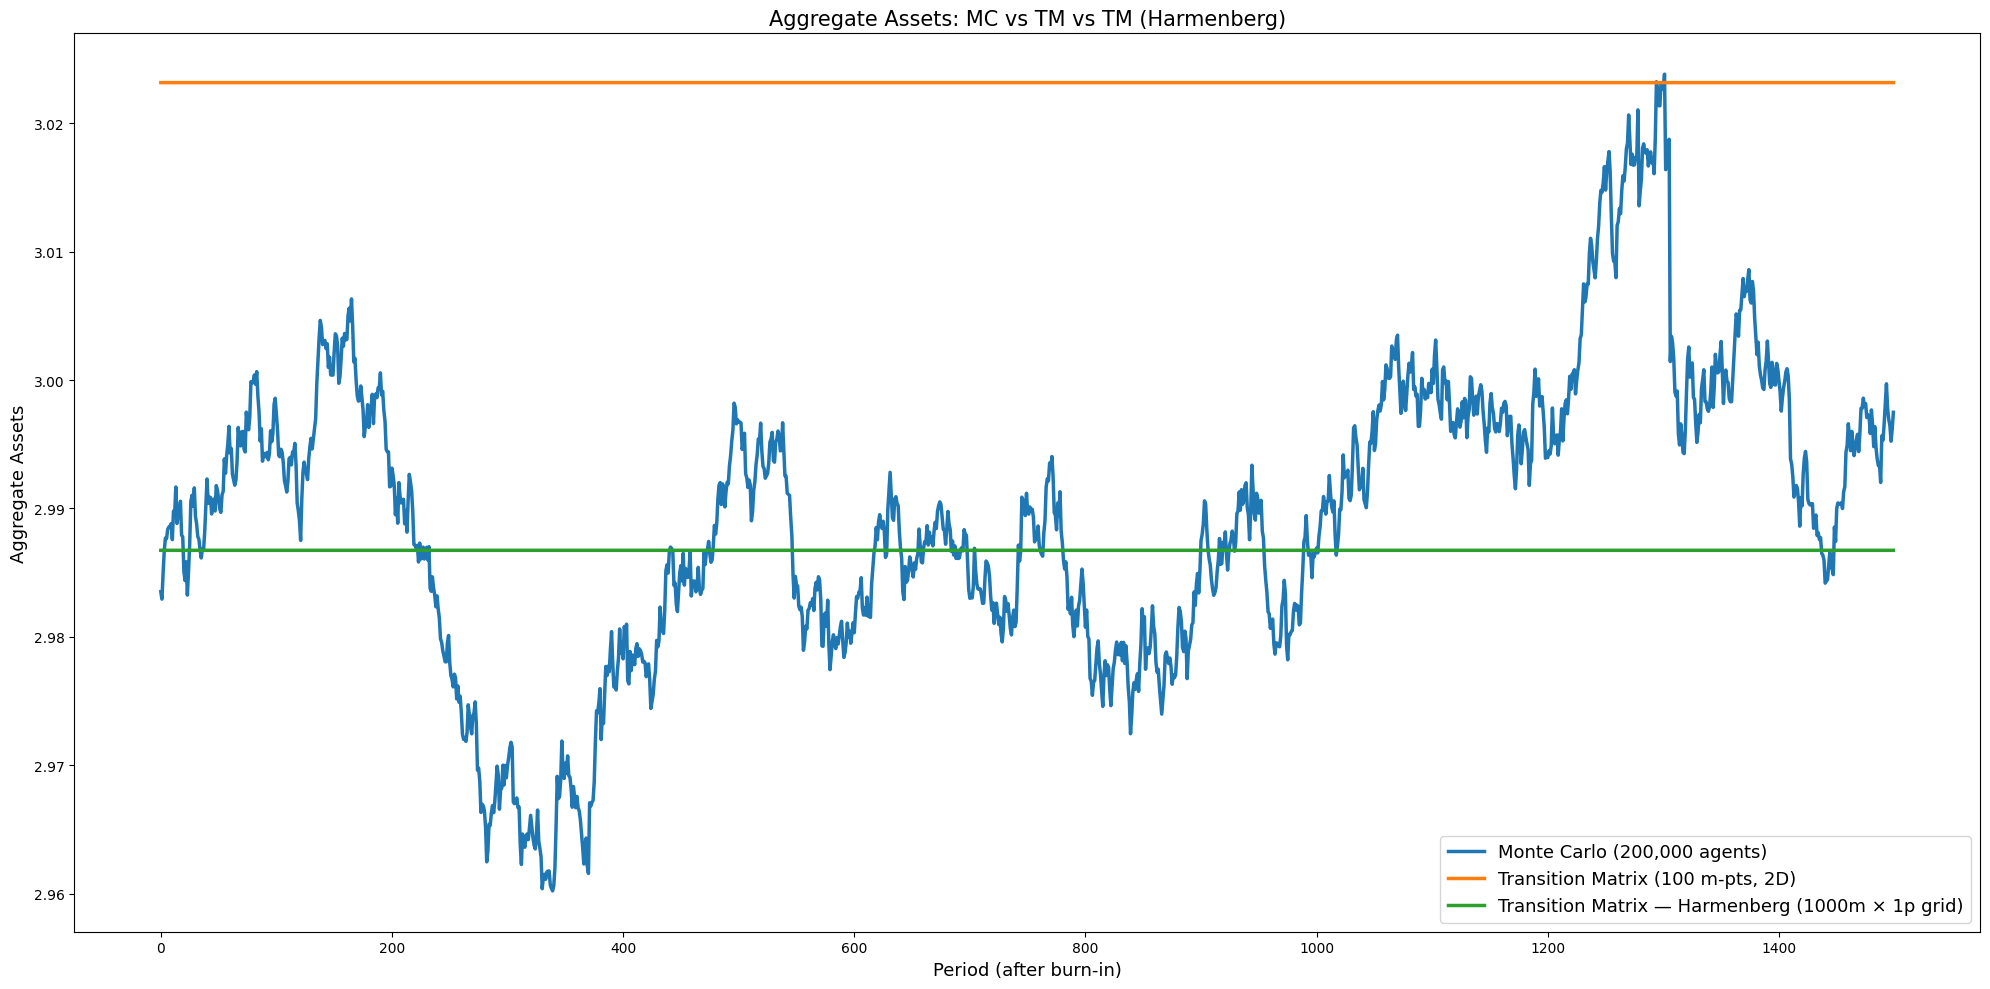

In [23]:
# [aggregate_assets_mc_tm_harmenberg] Aggregate assets paths — MC vs TM vs Harmenberg
n_m_harm = len(ss.dist_mGrid)

plt.figure(figsize=(20, 10))
plt.title("Aggregate Assets: MC vs TM vs TM (Harmenberg)")
plt.plot(aLvls[BURNIN:], label=f"Monte Carlo ({n_agents:,} agents)", color=COLOR_MC)
plt.plot(
    np.ones(example1.T_sim - BURNIN) * AggA,
    label=f"Transition Matrix ({n_m_grid} m-pts, 2D)",
    color=COLOR_TM,
)
plt.plot(
    np.ones(example1.T_sim - BURNIN) * AggA_fast,
    label=f"Transition Matrix — Harmenberg ({n_m_harm}m × 1p grid)",
    color=COLOR_HARM,
)
plt.ylabel("Aggregate Assets")
plt.xlabel("Period (after burn-in)")
plt.legend()
plt.tight_layout()
plt.show()

### Grid convergence

The accuracy of TM aggregates depends on the grid resolution.  The cell
below sweeps over several grid sizes and plots the resulting aggregate asset
levels against the MC benchmark.  Convergence to the MC mean as the grid is
refined confirms that the discretisation bias vanishes with sufficient grid
density.

In [24]:
Agg_AVals = []

mpoints = [200, 500, 1000]
for i in mpoints:
    ss.mCount = i

    ss.define_distribution_grid()
    ss.calc_transition_matrix()

    ss.calc_ergodic_dist()  # Calculate steady state distribution
    vecDstn_fast_sweep = ss.vec_erg_dstn
    Asset_val = np.dot(ss.aPol_Grid, vecDstn_fast_sweep)

    Agg_AVals.append(Asset_val)

# Use the finest resolution for all subsequent TM computations (transition path, MC initialization).
ss.mCount = 1000
ss.define_distribution_grid()
ss.calc_transition_matrix()
ss.calc_ergodic_dist()
vecDstn_fast = ss.vec_erg_dstn
c_ss = ss.cPol_Grid  # Steady-state consumption policy (used as terminal condition)
a_ss = ss.aPol_Grid  # Steady-state asset policy (used as terminal condition)

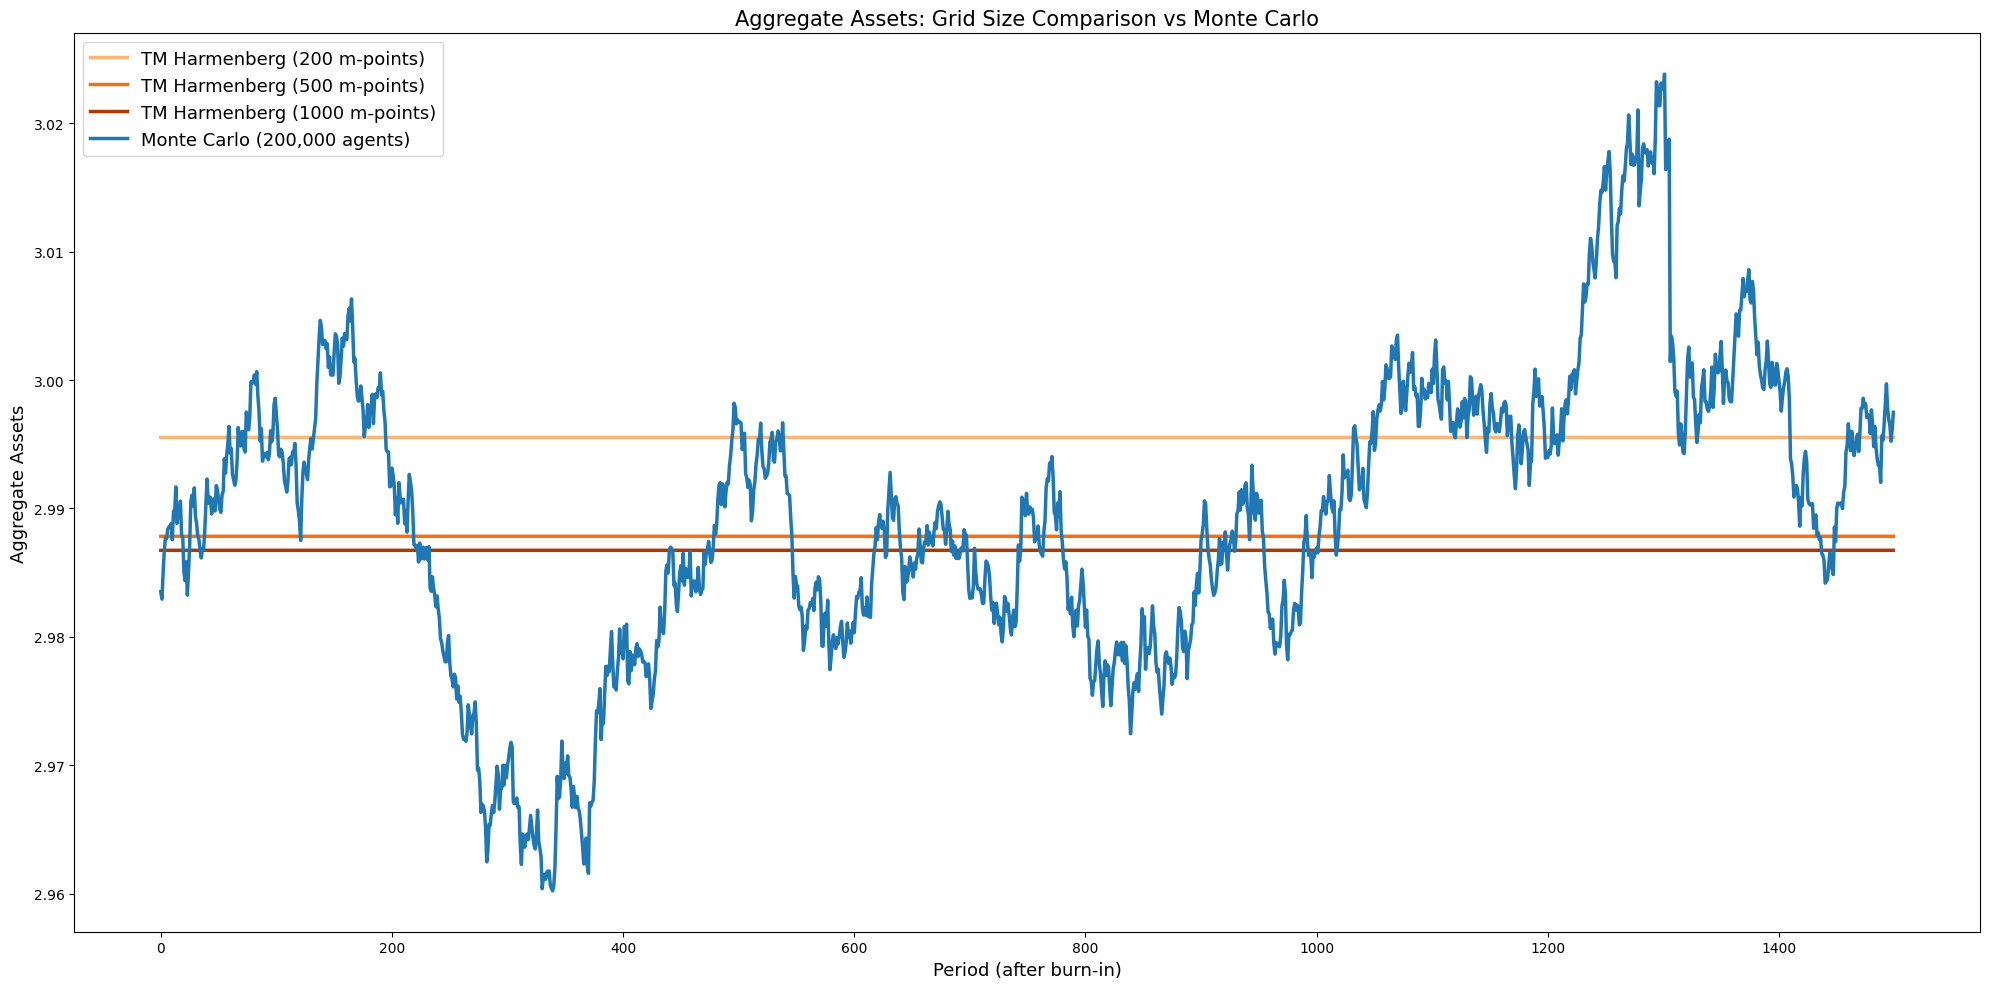

In [25]:
# [aggregate_assets_grid_comparison] Aggregate assets paths for multiple grid sizes vs MC
plt.figure(figsize=(20, 10))
plt.title("Aggregate Assets: Grid Size Comparison vs Monte Carlo")
grid_colors = plt.cm.Oranges(np.linspace(0.35, 0.85, len(Agg_AVals)))
for i in range(len(Agg_AVals)):
    plt.plot(
        np.ones(example1.T_sim - BURNIN) * Agg_AVals[i],
        label=f"TM Harmenberg ({mpoints[i]} m-points)",
        color=grid_colors[i],
    )
plt.plot(aLvls[BURNIN:], label=f"Monte Carlo ({n_agents:,} agents)", color=COLOR_MC)
plt.ylabel("Aggregate Assets")
plt.xlabel("Period (after burn-in)")
plt.legend()
plt.tight_layout()
plt.show()

The Harmenberg method thus provides two benefits simultaneously: it is
*faster* (1D vs 2D matrices) and *more accurate at the same computational
cost* (the savings in matrix size can be reinvested in a finer $m$-grid,
reducing discretisation error).

In [26]:
# Diagnostic: check that ergodic distribution has negligible mass near the boundary
tail_mass = np.sum(ss.vec_erg_dstn[-10:])
print(f"Mass in top 10 grid points: {tail_mass:.2e}")
if tail_mass > 1e-4:
    print("  Warning: non-negligible tail mass — consider increasing mMax.")
else:
    print("  OK: tail is well-resolved.")

Mass in top 10 grid points: 3.63e-08
  OK: tail is well-resolved.


### New API: Harmenberg via `norm="PermShk"`

In the new `AgentSimulator`, the Harmenberg neutral measure is activated by
passing `norm="PermShk"` to `make_transition_matrices()`.  This replaces the
legacy pattern of setting `neutral_measure = True` and calling
`update_income_process()`.  The permanent income dimension is automatically
collapsed, so the grid specification only needs to include `kNrm` (the
arrival variable) and any outcome variables of interest.

In [27]:
t0_harm_new = time.time()

_saved_track_vars_ss = ss.track_vars[:]
ss.track_vars = ["cNrm", "aNrm", "mNrm", "pLvl"]
ss.initialize_sym()
ss.track_vars = _saved_track_vars_ss
X_harm = ss._simulator

n_m_harm_new = ss.mCount
grid_specs_harm = {
    "kNrm": {"grid": ss.dist_mGrid},
    "cNrm": {"min": 0.0, "max": 5.0, "N": n_m_harm_new, "order": 3},
    "aNrm": {"grid": ss.dist_mGrid},
}
X_harm.make_transition_matrices(grid_specs_harm, norm="PermShk")
t1_harm_new = time.time()

X_harm.find_steady_state()
t2_harm_new = time.time()

AggA_harm_new = X_harm.get_long_run_average("aNrm")
AggC_harm_new = X_harm.get_long_run_average("cNrm")

print("=== New AgentSimulator API (Harmenberg, 1D grid) ===")
print(f"  make_transition_matrices : {t1_harm_new - t0_harm_new:6.2f}s")
print(f"  find_steady_state        : {t2_harm_new - t1_harm_new:6.2f}s")
print(f"  Total                    : {t2_harm_new - t0_harm_new:6.2f}s")
print()
print(f"  AgentSimulator Assets = {AggA_harm_new:.6f}")
print(f"  Legacy Harmenberg     = {float(np.asarray(AggA_fast).flat[0]):.6f}")
print(f"  AgentSimulator Cons   = {AggC_harm_new:.6f}")

=== New AgentSimulator API (Harmenberg, 1D grid) ===
  make_transition_matrices :   0.03s
  find_steady_state        :   0.02s
  Total                    :   0.04s

  AgentSimulator Assets = 2.606360
  Legacy Harmenberg     = 2.986742
  AgentSimulator Cons   = 1.020488


### Practical guidance for grid tuning

When using transition matrix methods, keep these rules of thumb in mind:

1. **Always use the Harmenberg neutral measure** for infinite-horizon problems (set `neutral_measure = True` before `update_income_process()`). It collapses the 2D $(m, p)$ grid to a 1D $m$ grid, dramatically reducing both computation time and discretization error. Only skip it if you specifically need the permanent income distribution.

2. **Use at least 1000 grid points** with Harmenberg. Low values of `mCount` (e.g. the default) are too coarse for many applications. With Harmenberg, using 1000–3000 points is fast and much more accurate.

3. **Check tail truncation.** If `mMax` is too small, probability mass piles up at the grid boundary. Verify that the ergodic distribution has negligible mass near the upper boundary: `print(sum(ss.vec_erg_dstn[-10:]))` should be very small.

4. **Use MC to cross-validate.** If MC and TM aggregates disagree substantially, the TM grid is probably too coarse — not an MC convergence problem. Increase grid points and check again.

5. **MC requires enough agents and burn-in.** Use at least 50,000 agents and discard at least 500 periods as burn-in. The standard error of MC aggregates scales as $\sigma / \sqrt{N}$.

### Monte Carlo simulation with Harmenberg trick

The Harmenberg neutral measure can also be applied to MC simulation: the
income process is reweighted so that the permanent income distribution
remains concentrated, reducing variance.  The cell below sets this up for
the finite-horizon agent, though the primary benefit of the neutral measure
is for TM computation.

In [28]:
ss.AgentCount = 200000
ss.T_sim = 2000
ss.initialize_sim()
ss.simulate()

## Part 3: Perfect-Foresight Transition Path

Both the TM and MC simulations are **initialised at the ergodic steady-state
distribution** computed above (`vecDstn_fast`).  The finite-horizon agent's
**terminal condition is the steady-state policy** (`ss.solution[0]`), so the
backward induction starts from — and, in the absence of any perturbation,
recovers — the infinite-horizon solution.

We solve a $T$-period finite-horizon problem in which a single-period
interest-rate deviation occurs at a known date $t^*$.  Agents have perfect
foresight of the entire path of aggregate variables.

In [29]:
T_cycle = 200
shock_t = 100
dx = -0.01

FinHorizonAgent = create_finite_horizon_agent(
    ss,
    Dict,
    T_cycle,
    shock_t,
    dx,
    orig_IncShkDstn,
)
FinHorizonAgent.track_vars = ["cNrm", "pLvl", "aNrm"]
FinHorizonAgent.T_sim = T_cycle
FinHorizonAgent.AgentCount = 400000

print(
    f"T_cycle={T_cycle}, shock_t={shock_t}, post-shock periods={T_cycle - shock_t - 1}"
)

T_cycle=200, shock_t=100, post-shock periods=99


### Construct the interest-rate path

We set the interest rate to its steady-state value in all periods except
$t = t^*$, where it is perturbed by $\Delta r$.  Because the finite-horizon
agent has time-varying `Rfree`, the backward-induction solver sees the
perturbation and adjusts all policies accordingly.

In [30]:
# Interest-rate path is set by create_finite_horizon_agent:
# R_ss in all periods except shock_t, where R_ss + dx applies.
R = ss.Rfree[0]
print(f"R_ss = {R:.6f}, dx = {dx}, R at t={shock_t}: {R + dx:.6f}")

R_ss = 1.016352, dx = -0.01, R at t=100: 1.006352


### Backward induction

Solve the finite-horizon problem by backward induction from $t = T-1$ to
$t = 0$.  The terminal condition is the steady-state solution, so the last
few periods' policies are nearly identical to steady state; only periods
near $t^*$ differ appreciably.

In [31]:
_t = time.time()
FinHorizonAgent.solve(presolve=False)
timings["fin_solve"] = time.time() - _t
print(f"FinHorizonAgent.solve: {timings['fin_solve']:.2f}s ({T_cycle} periods)")

FinHorizonAgent.solve: 0.11s (200 periods)


### Simulate with Monte Carlo (initialized from TM ergodic distribution)

Rather than relying on a long MC burn-in to reach steady state, we sample the initial MC population directly from the TM ergodic distribution using inverse-CDF interpolation. This ensures both methods start from the exact same distribution, so any discrepancy in the impulse responses is purely MC sampling noise vs. TM discretization error.

In [32]:
# PerfMITShk=True tells HARK to use the finite-horizon solution path when
# simulating, rather than the infinite-horizon steady-state policy.
FinHorizonAgent.PerfMITShk = True

# Use Harmenberg Improvement — REQUIRED by the TM grid setup below.
FinHorizonAgent.neutral_measure = True
FinHorizonAgent.update_income_process()

_t = time.time()
FinHorizonAgent.initialize_sim()
N_fin = FinHorizonAgent.AgentCount

# Initialize MC agents from the TM ergodic distribution via inverse-CDF sampling.
grid = ss.dist_mGrid
cdf = np.cumsum(vecDstn_fast)
cdf_with_zero = np.concatenate([[0.0], cdf])
grid_with_zero = np.concatenate([[grid[0]], grid])
u = np.random.uniform(0, 1, size=N_fin)
mNrm_init = np.interp(u, cdf_with_zero, grid_with_zero)
aNrm_init = np.interp(mNrm_init, grid, a_ss)
pLvl_init = np.ones(N_fin)
FinHorizonAgent.state_now["mNrm"] = mNrm_init
FinHorizonAgent.state_now["aNrm"] = aNrm_init
FinHorizonAgent.state_now["pLvl"] = pLvl_init

# Set t_age=1 so HARK doesn't suppress transitory shocks for "newborn" agents.
# (HARK sets TranShk=1.0 for agents with t_age=0, which would bias period-0 consumption.)
FinHorizonAgent.t_age = np.ones(N_fin, dtype=int)
FinHorizonAgent.simulate()
timings["mc_sim"] = time.time() - _t
print(f"MC simulation: {timings['mc_sim']:.2f}s ({N_fin:,} agents, {T_cycle} periods)")
clvl = []
alvl = []
for i in range(FinHorizonAgent.T_sim):
    clvl.append(np.mean(FinHorizonAgent.history["cNrm"][i, :]))
    alvl.append(np.mean(FinHorizonAgent.history["aNrm"][i, :]))

MC simulation: 13.23s (400,000 agents, 200 periods)


### New API: Finite-horizon MC via `symulate()`

The new simulation system handles finite-horizon (lifecycle) agents
automatically when `cycles > 0`.  Unlike the legacy system, there is no
need for the `PerfMITShk` flag — the simulator reads the period-specific
policy functions directly from the solution sequence.

In [33]:
FinHorizonAgent_new = create_finite_horizon_agent(
    ss, Dict, T_cycle, shock_t, dx, orig_IncShkDstn
)
FinHorizonAgent_new.solve(presolve=False)
FinHorizonAgent_new.track_vars = ["cNrm", "pLvl", "aNrm"]
FinHorizonAgent_new.T_sim = T_cycle
FinHorizonAgent_new.AgentCount = 200000

_t = time.time()
FinHorizonAgent_new.initialize_sym(stop_dead=False)
FinHorizonAgent_new.symulate()
timings["fin_mc_new"] = time.time() - _t

AggC_mc_new = np.array(
    [
        np.dot(
            FinHorizonAgent_new.hystory["cNrm"][i],
            FinHorizonAgent_new.hystory["pLvl"][i],
        )
        / FinHorizonAgent_new.AgentCount
        for i in range(T_cycle)
    ]
)

print(
    f"New symulate() MC: {timings['fin_mc_new']:.2f}s ({FinHorizonAgent_new.AgentCount:,} agents, {T_cycle} periods)"
)

New symulate() MC: 17.24s (200,000 agents, 200 periods)


### Build period-specific transition matrices (Harmenberg)

With the finite-horizon policies in hand, we construct one transition matrix
per period.  Under the Harmenberg neutral measure each matrix is 1D
($m$-grid only).  These matrices are stored densely by HARK's
`calc_transition_matrix()`, then converted to sparse format to reduce memory
from $O(T \cdot n^2)$ to $O(T \cdot \text{nnz})$.

#### Why sparse matrices matter here

A transition matrix for a Markov chain on $n$ grid points is $n \times n$,
but each column has only a handful of non-zero entries (one per income-shock
realisation that can reach a given next-period state).  With 1,000 grid
points the dense matrix occupies $1000^2 \times 8 \approx 7.6$ MB; the sparse
representation stores only the $O(n \cdot k)$ non-zeros (where $k$ is the
number of shock realisations), typically 50–100× smaller.  When the model
requires $T = 200$ such matrices, the difference is between ~1.5 GB of dense
storage and tens of MB of sparse storage.

The standard workflow is:

1. **Construct** entries in COO (coordinate / "triplet") format — just
   lists of `(row, col, value)` tuples — which is easy to build
   incrementally.
2. **Convert** to CSC (Compressed Sparse Column) or CSR (Compressed Sparse
   Row) format for fast arithmetic.  CSC is natural here because
   forward-propagating a distribution is a matrix–vector product
   $\boldsymbol{\pi}_{t+1} = \mathbf{T}_t \, \boldsymbol{\pi}_t$, and
   SciPy's CSC format is efficient for this operation.

For background on sparse matrix formats and when to use each, see the
[SciPy sparse tutorial](https://docs.scipy.org/doc/scipy/tutorial/sparse.html),
the [SciPy Cookbook on large Markov chains](https://scipy-cookbook.readthedocs.io/items/Solving_Large_Markov_Chains.html),
and the [CS 357 sparse matrix notes](https://cs357.cs.illinois.edu/textbook/notes/sparse.html)
from the University of Illinois.

> **Performance note:** HARK currently constructs each transition matrix as a
> dense NumPy array, then we convert to `scipy.sparse.csc_matrix`.  This
> dense-to-sparse conversion is the dominant cost in the TM branch of this
> notebook (see the timing summary below).  The right fix is to construct the
> matrices in sparse (COO) format directly inside the Numba-JIT inner loop
> that populates the matrix entries, avoiding the dense intermediate
> entirely.  This is a known improvement opportunity in HARK.
> [Tan (2020)](https://doi.org/10.1016/j.econlet.2020.109374) describes an
> alternative algorithm that avoids constructing the full transition matrix
> altogether, instead iterating the distribution forward directly — an
> approach that is both faster and more memory-efficient, particularly as
> the state space grows.

In [34]:
FinHorizonAgent.mCount = ss.mCount
FinHorizonAgent.mMax = ss.mMax
FinHorizonAgent.define_distribution_grid()

_t = time.time()
FinHorizonAgent.calc_transition_matrix()
timings["fin_calc_tm"] = time.time() - _t

dense_mb = sum(T.nbytes for T in FinHorizonAgent.tran_matrix) / 1024**2

_t2 = time.time()
FinHorizonAgent.tran_matrix = [sp.csc_matrix(T) for T in FinHorizonAgent.tran_matrix]
timings["sparse_convert"] = time.time() - _t2

sparse_mb = (
    sum(
        T.data.nbytes + T.indices.nbytes + T.indptr.nbytes
        for T in FinHorizonAgent.tran_matrix
    )
    / 1024**2
)
gc.collect()

print(f"calc_transition_matrix: {timings['fin_calc_tm']:.2f}s ({T_cycle} matrices)")
print(f"Sparse conversion: {timings['sparse_convert']:.2f}s")
print(
    f"  {dense_mb:.0f} MB -> {sparse_mb:.1f} MB ({dense_mb / sparse_mb:.0f}x reduction)"
)

calc_transition_matrix: 0.99s (200 matrices)
Sparse conversion: 2.19s
  1526 MB -> 98.0 MB (16x reduction)


### Forward propagation

Starting from the ergodic steady-state distribution, we propagate forward
through the sequence of period-specific transition matrices:
$\boldsymbol{\pi}_{t+1} = \mathbf{T}_t \, \boldsymbol{\pi}_t$.  At each
date we compute aggregate consumption and assets by integrating the
period-$t$ policy against the current distribution $\boldsymbol{\pi}_t$.

**Convention: column-stochastic matrices.**  HARK's transition matrices are
*column-stochastic*: each column sums to 1, and the $(i, j)$ entry gives the
probability of transitioning *from* grid point $j$ *to* grid point $i$.
Forward propagation is therefore a left-multiplication, $\mathbf{T} \boldsymbol{\pi}$
(equivalently `T @ pi` in NumPy / SciPy), not `pi @ T`.  This convention
differs from the row-stochastic matrices common in some textbooks, where
each *row* sums to 1 and the distribution is a row vector multiplied from
the left.

In [35]:
_t = time.time()

AggC_fast = []
AggA_fast = []

dstn = vecDstn_fast.copy()

c_ = list(FinHorizonAgent.cPol_Grid)
a_ = list(FinHorizonAgent.aPol_Grid)

c_.append(c_ss)
a_.append(a_ss)

for i in range(FinHorizonAgent.T_cycle):
    C = np.dot(c_[i], dstn)
    AggC_fast.append(C[0])

    A = np.dot(a_[i], dstn)
    AggA_fast.append(A[0])

    dstn = FinHorizonAgent.tran_matrix[i] @ dstn

AggC_fast = np.array(AggC_fast).T
AggA_fast = np.array(AggA_fast).T

timings["fwd_prop"] = time.time() - _t

del FinHorizonAgent.tran_matrix
gc.collect()
print(f"Forward propagation: {timings['fwd_prop']:.2f}s ({T_cycle} periods)")

Forward propagation: 0.01s (200 periods)


### New API: Forward propagation via `simulate_cohort_by_grids()`

The new `AgentSimulator` provides `simulate_cohort_by_grids()` as a
one-call replacement for the manual loop that multiplies transition matrices
by the state distribution.  It takes the outcome variable names and an
optional initial distribution, and stores the resulting time series of
averages in `_simulator.history_avg`.

In [36]:
_t = time.time()

_saved_tv_fin = FinHorizonAgent.track_vars[:]
FinHorizonAgent.track_vars = ["cNrm", "aNrm", "mNrm", "pLvl"]
FinHorizonAgent.initialize_sym()
FinHorizonAgent.track_vars = _saved_tv_fin
X_fin = FinHorizonAgent._simulator
X_fin.make_transition_matrices(grid_specs_harm, norm="PermShk")

X_fin.simulate_cohort_by_grids(
    ["cNrm", "aNrm"],
    T_max=T_cycle,
    calc_avg=True,
    from_dstn=X_harm.steady_state_dstn,
)
timings["fin_tm_new"] = time.time() - _t

AggC_new_path = X_fin.history_avg["cNrm"]
AggA_new_path = X_fin.history_avg["aNrm"]

print(
    f"New AgentSimulator forward propagation: {timings['fin_tm_new']:.2f}s ({T_cycle} periods)"
)
print(
    f"  Max |C_old - C_new|: {np.max(np.abs(np.array(AggC_fast) - AggC_new_path)):.2e}"
)
print(
    f"  Max |A_old - A_new|: {np.max(np.abs(np.array(AggA_fast) - AggA_new_path)):.2e}"
)

New AgentSimulator forward propagation: 7.28s (200 periods)
  Max |C_old - C_new|: 1.31e-02
  Max |A_old - A_new|: 3.80e-01


### Path of Aggregate Consumption — Perfect-Foresight Transition


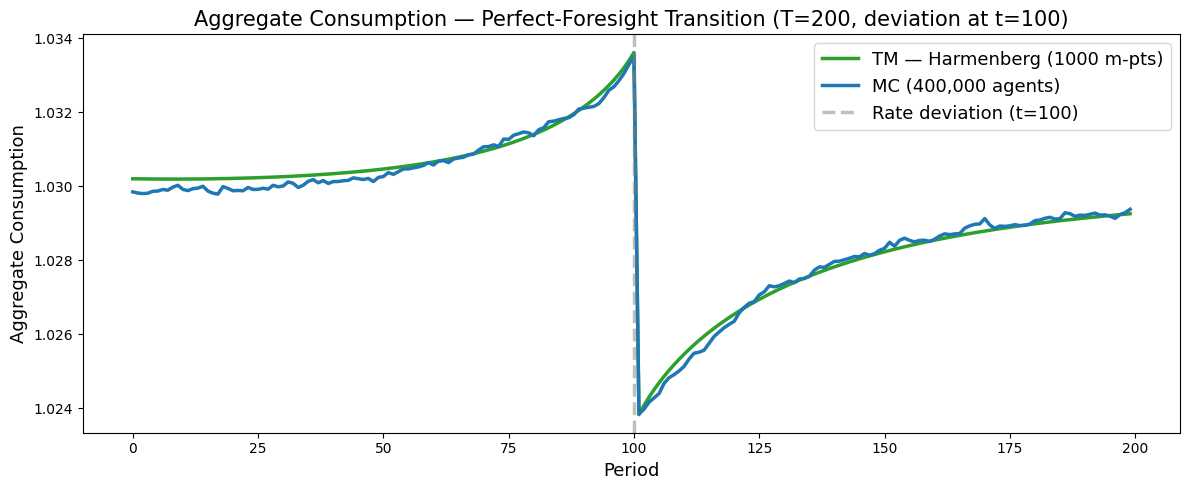

In [37]:
# [aggregate_consumption_harmenberg] Aggregate consumption — perfect-foresight transition path
n_m_irf = len(ss.dist_mGrid)

plt.figure(figsize=(12, 5))
plt.title(
    f"Aggregate Consumption — Perfect-Foresight Transition (T={T_cycle}, deviation at t={shock_t})"
)
plt.plot(
    range(T_cycle),
    AggC_fast[:T_cycle],
    label=f"TM — Harmenberg ({n_m_irf} m-pts)",
    color=COLOR_HARM,
)
plt.plot(
    range(T_cycle),
    clvl[:T_cycle],
    label=f"MC ({N_fin:,} agents)",
    color=COLOR_MC,
)
plt.axvline(
    x=shock_t,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label=f"Rate deviation (t={shock_t})",
)
plt.xlabel("Period")
plt.ylabel("Aggregate Consumption")
plt.legend()
plt.tight_layout()
plt.show()

### Path of Aggregate Assets — Perfect-Foresight Transition


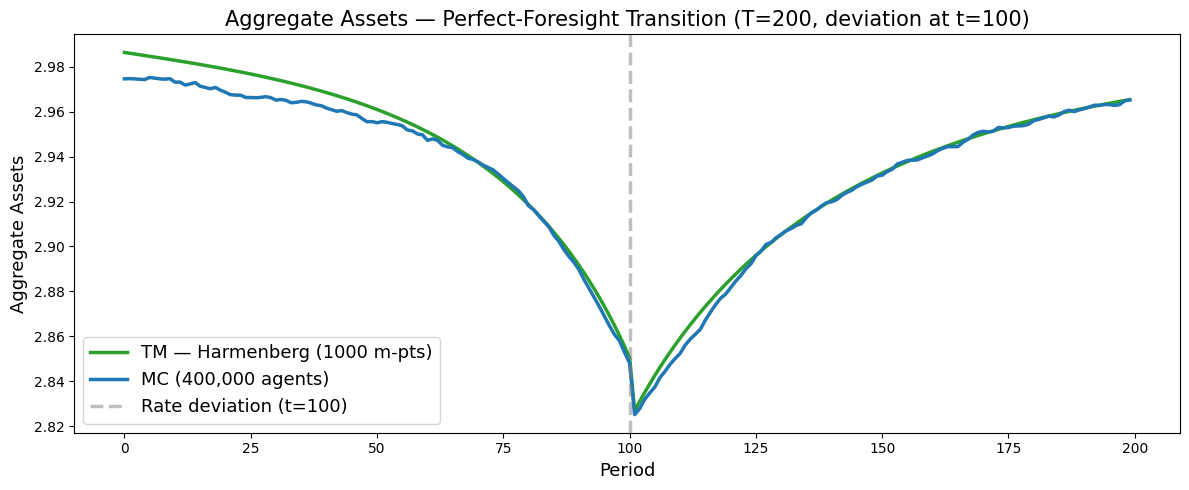

In [38]:
# [aggregate_assets_harmenberg] Aggregate assets — perfect-foresight transition path
plt.figure(figsize=(12, 5))
plt.title(
    f"Aggregate Assets — Perfect-Foresight Transition (T={T_cycle}, deviation at t={shock_t})"
)
plt.plot(
    range(T_cycle),
    AggA_fast[:T_cycle],
    label=f"TM — Harmenberg ({n_m_irf} m-pts)",
    color=COLOR_HARM,
)
plt.plot(
    range(T_cycle),
    alvl[:T_cycle],
    label=f"MC ({N_fin:,} agents)",
    color=COLOR_MC,
)
plt.axvline(
    x=shock_t,
    color="gray",
    linestyle="--",
    alpha=0.5,
    label=f"Rate deviation (t={shock_t})",
)
plt.xlabel("Period")
plt.ylabel("Aggregate Assets")
plt.legend()
plt.tight_layout()
plt.show()

### Interpreting the transition path

The shape of the response follows from standard consumption-savings logic:

- **Before $t^*$ (anticipation window):** Agents know that the interest rate
  will be temporarily lower at $t^*$, reducing the return on saving.  They
  begin consuming more and saving less *before* the deviation arrives,
  so aggregate consumption rises and aggregate assets decline in advance.
- **At $t^*$:** The rate deviation hits.  The lower return on saving further
  encourages consumption.  Aggregate consumption spikes and assets drop
  sharply.
- **After $t^*$:** The interest rate returns to steady state.  Agents
  gradually rebuild their depleted asset holdings, so consumption falls
  below steady state temporarily while assets recover.  Both aggregates
  converge back to the ergodic steady state from below/above as the
  transitory effect dissipates.

### Extracting a numerical Jacobian column

The directory containing this notebook is named `SequenceSpaceJacobians` for
a reason: the transition path computed above is the building block for SSJ
Jacobians.  In the linearised SSJ framework, column $s$ of the Jacobian
$\mathbf{J}_{C,r}$ gives the response of the aggregate consumption *sequence*
to a unit perturbation in the interest rate at date $s$.  We can extract this
column numerically by dividing the deviation of the transition path from
steady state by the perturbation size $\Delta r$:

$$J_{C,r}^{(s)}(t) \;\approx\; \frac{C_t(\Delta r) - C^{ss}}{\Delta r}$$

This is valid when $\Delta r$ is small enough that the response is
approximately linear.

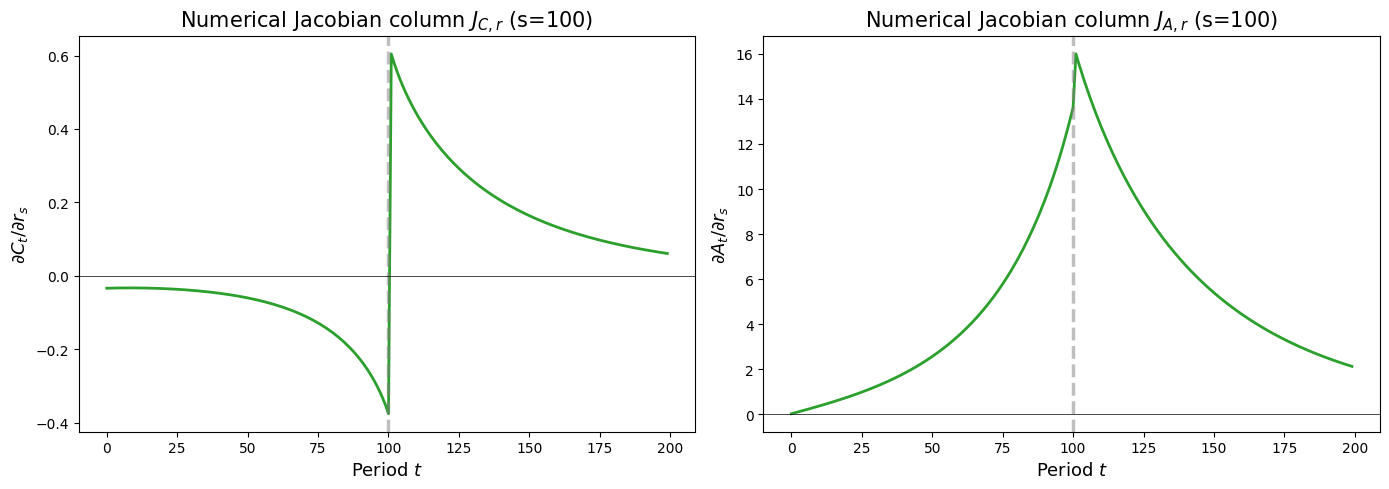

In [39]:
c_ss_scalar = np.asarray(np.dot(c_ss, vecDstn_fast)).flat[0]
a_ss_scalar = np.asarray(np.dot(a_ss, vecDstn_fast)).flat[0]

J_C = (np.array(AggC_fast) - c_ss_scalar) / dx
J_A = (np.array(AggA_fast) - a_ss_scalar) / dx

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(J_C, color=COLOR_HARM, linewidth=2)
axes[0].axvline(x=shock_t, color="gray", linestyle="--", alpha=0.5)
axes[0].axhline(y=0, color="black", linewidth=0.5)
axes[0].set_title(f"Numerical Jacobian column $J_{{C,r}}$ (s={shock_t})")
axes[0].set_xlabel("Period $t$")
axes[0].set_ylabel("$\\partial C_t / \\partial r_s$")

axes[1].plot(J_A, color=COLOR_HARM, linewidth=2)
axes[1].axvline(x=shock_t, color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_title(f"Numerical Jacobian column $J_{{A,r}}$ (s={shock_t})")
axes[1].set_xlabel("Period $t$")
axes[1].set_ylabel("$\\partial A_t / \\partial r_s$")

plt.tight_layout()
plt.show()

### Linearity check

If the perturbation is small enough for the linear approximation to hold,
then the Jacobian column should be independent of `dx`.  We verify this by
recomputing the transition path at a smaller perturbation and checking that
the rescaled paths overlap.

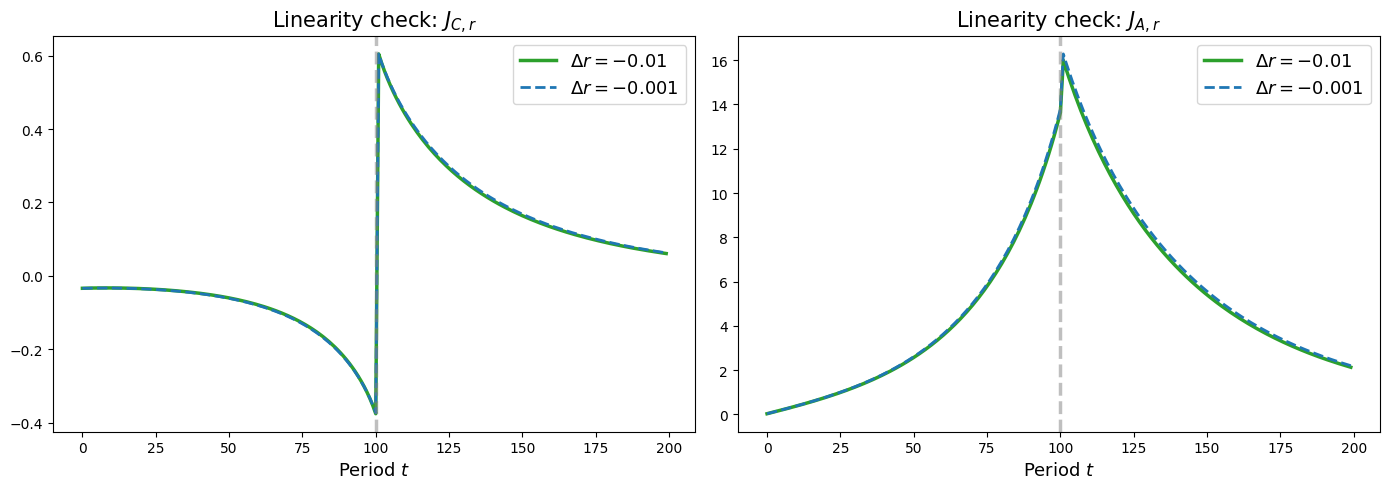

Max |J_C difference|: 0.005811
Max |J_A difference|: 0.290639


In [40]:
dx_small = dx / 10.0

FinHorizonAgent_check = create_finite_horizon_agent(
    ss,
    Dict,
    T_cycle,
    shock_t,
    dx_small,
    orig_IncShkDstn,
)
FinHorizonAgent_check.solve(presolve=False)

FinHorizonAgent_check.neutral_measure = True
FinHorizonAgent_check.update_income_process()
FinHorizonAgent_check.mCount = ss.mCount
FinHorizonAgent_check.mMax = ss.mMax
FinHorizonAgent_check.mMin = ss.mMin
FinHorizonAgent_check.mFac = ss.mFac
FinHorizonAgent_check.define_distribution_grid()
FinHorizonAgent_check.calc_transition_matrix()

dstn_chk = vecDstn_fast.copy()
AggC_chk, AggA_chk = [], []
for i in range(T_cycle):
    AggC_chk.append(np.dot(FinHorizonAgent_check.cPol_Grid[i], dstn_chk)[0])
    AggA_chk.append(np.dot(FinHorizonAgent_check.aPol_Grid[i], dstn_chk)[0])
    dstn_chk = FinHorizonAgent_check.tran_matrix[i] @ dstn_chk

J_C_small = (np.array(AggC_chk) - c_ss_scalar) / dx_small
J_A_small = (np.array(AggA_chk) - a_ss_scalar) / dx_small

del FinHorizonAgent_check
gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(J_C, label=f"$\\Delta r = {dx}$", color=COLOR_HARM, linewidth=2.5)
axes[0].plot(
    J_C_small,
    label=f"$\\Delta r = {dx_small}$",
    color=COLOR_MC,
    linewidth=2,
    linestyle="--",
)
axes[0].axvline(x=shock_t, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("Linearity check: $J_{C,r}$")
axes[0].set_xlabel("Period $t$")
axes[0].legend()

axes[1].plot(J_A, label=f"$\\Delta r = {dx}$", color=COLOR_HARM, linewidth=2.5)
axes[1].plot(
    J_A_small,
    label=f"$\\Delta r = {dx_small}$",
    color=COLOR_MC,
    linewidth=2,
    linestyle="--",
)
axes[1].axvline(x=shock_t, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title("Linearity check: $J_{A,r}$")
axes[1].set_xlabel("Period $t$")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Max |J_C difference|: {np.max(np.abs(J_C - J_C_small)):.6f}")
print(f"Max |J_A difference|: {np.max(np.abs(J_A - J_A_small)):.6f}")

In [41]:
print(f"{'=' * 60}")
print(f"TIMING SUMMARY  (T_cycle={T_cycle}, shock_t={shock_t}, mCount={ss.mCount})")
print(f"{'=' * 60}")
labels = {
    "ss_solve": "SS model solve",
    "ss_tm": f"SS transition matrix ({ss.mCount} m-pts)",
    "fin_solve": f"Finite-horizon solve ({T_cycle} periods)",
    "mc_sim": f"MC simulation ({FinHorizonAgent.AgentCount:,} agents)",
    "fin_calc_tm": f"Finite-horizon TMs ({T_cycle} matrices)",
    "sparse_convert": "Dense -> sparse conversion",
    "fwd_prop": f"TM forward propagation ({T_cycle} periods)",
}
total = 0.0
for key, label in labels.items():
    t = timings.get(key, 0.0)
    total += t
    print(f"  {label:.<50s} {t:6.2f}s")
print(f"  {'TOTAL':.<50s} {total:6.2f}s")

TIMING SUMMARY  (T_cycle=200, shock_t=100, mCount=1000)
  SS model solve....................................   0.00s
  SS transition matrix (1000 m-pts).................   0.00s
  Finite-horizon solve (200 periods)................   0.11s
  MC simulation (400,000 agents)....................  13.23s
  Finite-horizon TMs (200 matrices).................   0.99s
  Dense -> sparse conversion........................   2.19s
  TM forward propagation (200 periods)..............   0.01s
  TOTAL.............................................  16.54s


## Concluding Observations

The timing summary above shows that Monte Carlo and transition matrix methods
have roughly comparable computation times (both in the range of 10–20 seconds
for this exercise).  But the *precision* of the two approaches differs
enormously: the TM path is smooth and deterministic, while the MC path
exhibits visible sampling noise even with 400,000 simulated agents — a
population far larger than would be feasible in models that are meaningfully
more complex than the simple one studied here.

Three practical lessons emerge:

1. **Grid density matters for TM accuracy.**  When the transition matrix grid
   is insufficiently dense — or is dense in the wrong regions of the state
   space — computed aggregate levels can be substantially wrong.  In the
   experiments here, grids for normalized market resources at the lower end
   of those used in the cited literature (50–100 points) produced
   substantially biased steady-state distributions, particularly for
   permanent income and market resources in levels.  A double-exponential
   grid with 1000 points for the Harmenberg 1D case, however, produced
   estimates that were both accurate (judged by close agreement with Monte
   Carlo simulations using 200,000+ agents) and precise (deterministic, with
   no sampling noise).  This underscores the value of performing
   steady-state analysis using *both* MC and TM methods: MC provides an
   unbiased (if noisy) benchmark against which TM discretisation error can
   be assessed, and one should adjust the structure and density of the TM
   grid until the two methods agree.

2. **The Harmenberg neutral measure is essential for models with permanent
   shocks.**  By reweighting the permanent income distribution
   ([Harmenberg, 2021](https://doi.org/10.1016/j.jedc.2021.104185)), it collapses the two-dimensional $(m, p)$ state
   space to a one-dimensional $m$ grid.  This dramatically reduces the size of
   the transition matrices needed for accurate and precise results — from
   thousands-by-thousands 2D matrices to manageable 1D vectors — making
   high-resolution TM computation practical.

3. **MC is a poor tool for computing predictable model dynamics.**  The
   sampling noise inherent in Monte Carlo simulation introduces fluctuations
   that obscure the signal of interest, particularly for small perturbations
   such as realistic interest-rate deviations.  This noise is visible even at
   400,000 agents and would be worse at the smaller agent counts needed for
   more complex models.  Transition matrix methods are the right tool for
   computing perfect-foresight transition paths, impulse responses, and
   sequence-space Jacobians, where deterministic precision is essential.

### Partial equilibrium and the path to general equilibrium

Everything computed in this notebook is a **partial-equilibrium** calculation:
the interest rate path is taken as given, and we compute how the distribution
of agents responds.  In a general-equilibrium HANK model, prices (interest
rates, wages) are themselves endogenous — they adjust until markets clear.

The SSJ framework of
[Auclert, Bardóczy, Rognlie, and Straub (2021)](https://doi.org/10.3982/ECTA17434)
closes the GE loop by assembling partial-equilibrium Jacobian columns (like
the ones extracted above) into a system of linearised equations.  The
Jacobian matrix $\mathbf{J}_{C,r}$ — whose column $s$ is the PE response of
the consumption sequence to a rate perturbation at date $s$ — enters the GE
condition that aggregate consumption must equal aggregate output net of
investment.  Stacking these conditions for all dates yields a linear system
whose solution gives the GE impulse response.  The transition-path
computation in this notebook is therefore the core *inner step* of the SSJ
algorithm; extending it to GE requires specifying a production side and
market-clearing conditions, then iterating on prices.

## Appendix: Legacy-to-New API Migration Guide

Throughout this notebook, the "New API" cells demonstrated the `AgentSimulator`
equivalents of the legacy transition-matrix methods.  The table below
summarises the mapping.

| Legacy method | New `AgentSimulator` equivalent |
|---|---|
| `define_distribution_grid()` | `grid_specs` dict passed to `make_transition_matrices()` |
| `calc_transition_matrix()` | `_simulator.make_transition_matrices(grid_specs)` |
| `calc_ergodic_dist()` | `_simulator.find_steady_state()` |
| `neutral_measure=True` + `update_income_process()` | `norm="PermShk"` arg to `make_transition_matrices()` |
| `initialize_sim()` + `simulate()` | `initialize_sym()` + `symulate()` |
| `history` dict | `hystory` dict |
| `tran_matrix` | `_simulator.trans_arrays` |
| `vec_erg_dstn` | `_simulator.steady_state_dstn` |
| `cPol_Grid` / `aPol_Grid` | `_simulator.outcome_arrays` + `outcome_grids` |
| Manual forward-prop loop | `_simulator.simulate_cohort_by_grids()` |
| `calc_jacobian()` | `make_basic_SSJ()` (via `HARK.SSJutils`) |

**Key advantages of the new system:**

- **General-purpose:** Works with any `AgentType` that has a YAML model file,
  not just `NewKeynesianConsumerType`.
- **Declarative grids:** Grid specifications are plain dictionaries rather than
  method arguments, making them easier to modify and pass around.
- **Harmenberg built in:** The neutral measure is a single argument (`norm`)
  rather than requiring manual income-process manipulation.
- **One-call forward propagation:** `simulate_cohort_by_grids()` replaces
  hand-written matrix-vector loops.
- **Model introspection:** `_simulator.describe()` shows the full parsed model
  structure, including variable roles and dynamics.

## Related Tools and Resources

Several other open-source toolkits implement the methods used in this
notebook.

**Sequence-Space Jacobian (SSJ) toolkit.**  The Python package accompanying
[Auclert, Bardóczy, Rognlie, and Straub (2021)](https://doi.org/10.3982/ECTA17434)
provides a general framework for computing Jacobians and perfect-foresight
transition paths in heterogeneous-agent models.  The
[SSJ GitHub repository](https://github.com/shade-econ/sequence-jacobian)
includes worked examples for RBC, one-asset HANK, and two-asset HANK models,
including nonlinear transition-path calculations closely analogous to what
this notebook does.

**McKay's lecture notes.**  Alisdair McKay's
[*Heterogeneous Agent Models*](https://alisdairmckay.com/Notes/HetAgentsV2/)
notes provide a clear pedagogical treatment of the computational methods,
including a standalone chapter on
[perfect-foresight transitions](https://alisdairmckay.com/Notes/HetAgentsV2/MIT)
whose backward-induction / forward-propagation algorithm is the one
implemented here.

**Den Haan's comparison project.**  [Den Haan (2010)](https://doi.org/10.1016/j.jedc.2009.06.001)
organised a systematic comparison of numerical methods for solving
heterogeneous-agent models (histogram methods, parameterised distributions,
projection, perturbation).  The
[companion website](https://www.wouterdenhaan.com/numerical.htm) collects
code and accuracy benchmarks from multiple contributors.  The transition
matrix method used here is a descendant of the histogram approach evaluated
in that comparison.

**Other toolkits.**
[BASEforHANK](https://github.com/BASEforHANK/BASEtoolbox.jl) (Julia)
implements the methods of
[Bayer and Luetticke (2020)](https://doi.org/10.3982/ECTA16317) using
perturbation around the stationary distribution.
[Econforge/dolo](https://github.com/EconForge/dolo) (Python) provides a
model-specification language and solvers for dynamic economic models,
including heterogeneous-agent problems.